# Phân tích dữ liệu và các yếu tố tác động đến giá nhà trọ
## 1. Phát biểu bài toán 
- Mục tiêu của bài toán là Khảo sát dữ liệu về phòng trọ sinh viên tại 3 thành phố Đà Nẵng, Hà Nội và Hồ Chí Minh nhằm xác định các đặc trưng quan trọng ảnh hưởng đến giá thuê phòng trọ. Từ đó, đánh giá tính khả thi cho việc xây dựng mô hình dự đoán với biến mục tiêu (target variable) $Y$ là Giá cho thuê từ các biến/đặc trưng $X_i$ (Diện tích, vị trí, tiện ích).
- Loại bài toán mô hinh hóa: Do biến mục tiêu $Y$ (Giá cho thuê) đã được xác định cụ thể và là một biến số thực (liên tục), nên việc mô hình hóa ở tương lại sẽ là bài toán Hồi quy (Regression).
- Tính khả thi: Dữ liệu có tính khả thi khá cao vì có sự tương quan tuyến tính/phi tuyến rõ rệt (Diện tích tỷ lệ thuận với giá, Tiện ích càng nhiều thì giá càng cao).
- Tập đặc trưng hữu ích ($X_i$) đề xuất `Diện tích`, `Thành phố`, `Quận/Huyện`, và Các tiện ích (Máy lạnh, Thang máy, Giờ tự do,...).

## 2. Thu thập dữ liệu
- Nguồn dữ liệu: Dữ liệu được crawl từ trang web đăng tin nhà trọ tại phongtro123.com
- Số lượng mẫu: 2657 mẫu (mỗi thành phố cào 50 trang dữ liệu).
- Số lượng biến: 
    + Mã_Tin: ID định danh của bài đăng.
    + Thời_Gian_Đăng: Thời gian cập nhật tin.
    + Thành_Phố, Quận_Huyện: Vị trí địa lý.
    + Giá_Cho_Thuê: Giá thuê hàng tháng (Triệu VNĐ).
    + Diện_Tích_m2: Diện tích sử dụng (m2).
    + Tiêu_Đề, Mô_Tả, Nổi_Bật: Các trường văn bản phi cấu trúc (Unstructured Text) chứa thông tin quảng cáo chi tiết do chủ trọ tự viết.

### Cách thức thu thập
- Mô tả thu thập: Dữ liệu tự thu thập (crawl) bằng cách sử dụng kỹ thuật web scraping từ trang web phongtro123.com, nơi có nhiều tin đăng về phòng trọ sinh viên tại các thành phố lớn. Để vượt qua cơ chế chống bot (tường lửa Cloudflare) của trang web, nhóm đã sử dụng thư viện `cloudscraper` kết hợp với `BeautifulSoup` trong Python. Thông tin được bóc tách trực tiếp từ cấu trúc `JSON-LD` nhúng trong mã nguồn HTML, đảm bảo tính chính xác tuyệt đối. Dữ liệu sau đó được lưu trữ vào file CSV.


## 3. Thống kê mô tả dữ liệu

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

### Load raw data

In [6]:
plt.rcParams['font.family'] = 'sans-serif'
plt.style.use('ggplot')

# Load raw data
df_raw = pd.read_csv('../data_phongtro/crawl/raw_data.csv')

### Thống kê tổng quan về tập dữ liệu thô

In [7]:
print("THÔNG TIN TỔNG QUAN VỀ TẬP DỮ LIỆU THÔ")
print(f"Tổng số mẫu trong tập dữ liẹu: {df_raw.shape[0]} mẫu.")
print(f"Tổng số đặc trưng (cột) trong tập dữ liệu: {df_raw.shape[1]} biến.")

THÔNG TIN TỔNG QUAN VỀ TẬP DỮ LIỆU THÔ
Tổng số mẫu trong tập dữ liẹu: 2657 mẫu.
Tổng số đặc trưng (cột) trong tập dữ liệu: 9 biến.


### Xem trước 5 dòng của file raw_data

In [21]:
display(df_raw.head(5))

,Mã_Tin,Thời_Gian_Đăng,Thành_Phố,Quận_Huyện,Giá_Cho_Thuê,Diện_Tích_m2,Tiêu_Đề,Mô_Tả,Nổi_Bật
0,700456,"Thứ 7, 08:51 07/03/2026",Đà Nẵng,Liên Chiểu,2.7,18.0,Cho thue phòng trọ - Homestay full nội thất gi...,"Cho thue phong trọ - Homestay full nội thất, p...","Đầy đủ nội thất, Có gác, Có kệ bếp, Có máy lạn..."
1,702397,"Thứ 2, 21:28 09/03/2026",Đà Nẵng,Hải Châu,4.0,30.0,"Cho thuê phòng số 79 Hoá Sơn 6, Đà Nẵng",CHO THUÊ PHÒNG NGỦ FULL NỘI THẤT – ĐƯỜNG HÓA S...,"Đầy đủ nội thất, Có gác, Có kệ bếp, Có máy lạn..."
2,702779,"Thứ 4, 14:14 11/03/2026",Đà Nẵng,Hải Châu,1.7,18.0,"Cho thuê phòng trọ gần sân bay, ưu tiên nữ sin...","cho thuê phòng trọ 1 người ở gần sân bay, ưu t...",NaN
3,702424,"Thứ 5, 08:50 05/03/2026",Đà Nẵng,Cẩm Lệ,3.3,20.0,"CHO THUÊ PHÒNG TRỌ Khu vực Đại học Kiến trúc, ...","Phòng diện tích 20m², có gác lửng, điều hoà, n...","Đầy đủ nội thất, Có gác, Có kệ bếp, Có máy lạn..."
4,593254,"Thứ 5, 18:28 26/02/2026",Đà Nẵng,Ngũ Hành Sơn,2.0,20.0,Cho thuê phòng trọ giá rẻ khu vực ngay chợ Non...,"Cho thuê nhà ngay chợ Non Nước , gần nhiều trư...","Đầy đủ nội thất, Có gác, Có kệ bếp, Có máy lạn..."


### Thông tin về các biến

In [16]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 2657 entries, 0 to 2656
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Mã_Tin          2657 non-null   int64  
 1   Thời_Gian_Đăng  2657 non-null   str    
 2   Thành_Phố       2657 non-null   str    
 3   Quận_Huyện      2657 non-null   str    
 4   Giá_Cho_Thuê    2657 non-null   float64
 5   Diện_Tích_m2    2657 non-null   float64
 6   Tiêu_Đề         2657 non-null   str    
 7   Mô_Tả           2657 non-null   str    
 8   Nổi_Bật         1619 non-null   str    
dtypes: float64(2), int64(1), str(6)
memory usage: 186.9 KB


In [20]:
df_raw[['Giá_Cho_Thuê', 'Diện_Tích_m2']].describe().round(2)

,Giá_Cho_Thuê,Diện_Tích_m2
count,2657.00,2657.00
mean,3.17,27.32
std,1.48,16.32
min,0.00,0.00
25%,2.00,20.00
50%,3.00,25.00
75%,4.00,30.00
max,24.00,350.00


### Nhận xét từ thống kê mô tả:
**1. Về dữ liệu trống (Missing Values):**
- Đa số các biến quan trọng như `Thành_Phố`, `Quận_Huyện`, `Giá_Cho_Thuê`, `Diện_Tích_m2` và đặc biệt là văn bản `Mô_Tả` đều có 2657/2657 quan sát (Hoàn toàn không bị Null/NaN).
- Riêng cột `Nổi_Bật` chỉ có 1619 giá trị (thiếu 1038 giá trị). Thực tế vì không phải chủ trọ nào cũng mua gói "Tin VIP" để hệ thống tự động tick chọn các tiện ích nổi bật.

**2. Về dữ liệu định lượng (Giá và Diện tích):**
- Mức trung bình của phòng trọ sinh viên là khoảng **3.17 triệu/tháng** với diện tích **27.3 m2**
- **Tồn tại Ngoại lệ (Outliers) và Dữ liệu lỗi:** 
    + Cả Giá và Diện tích đều có giá trị `Min = 0.00`. Đây là dữ liệu rác/lỗi nhập liệu từ phía người dùng trên website (vi dụ: trong trường hợp giá thỏa thuận)
    + Mức `Max` của Giá lên tới **24 triệu/tháng** và Diện tích lên tới **350 m2**. Đây không nằm trong phạm vi "phòng trọ sinh viên" mà bài toán đang hướng tới.

**3. Về dữ liệu văn bản (Text Data):**
- Tập dữ liệu hiện tại chỉ chứa các thông tin phi cấu trúc ở `Tiêu_Đề`, `Mô_Tả`, `Nổi_Bật`. Máy tính không thể trực tiếp chạy mô hình tương quan trên các đoạn văn bản này.

### Trực quan hóa và phân tích đơn biến
- Sau khi có cái nhìn tổng quan các con số thống kê mô tả, tiến hành trực quan hóa phân bố của các biến quan trọng trong bài toán. Ba biến được lựa chọn để phân tích là:
    + **Thành_Phố**: Biến danh mục - Đánh giá sự phân bổ nguồn cung dữ liệu giữa các khu vực.
    + **Giá_Cho_Thuê**: Biến mục tiêu $Y$ định lượng - Kiểm tra xem phân phối của giá có đạt chuẩn (Normal Distribution) hay bị lệch, từ đó quyết định phương pháp chuẩn hóa toán học ở bước sau..
    + **Diện_Tích_m2**: Biến độc lập $X_i$ định lượng. - Đánh giá sự tập trung của diện tích phòng ở thực tế và dò tìm các điểm dị biệt (Outliers). 

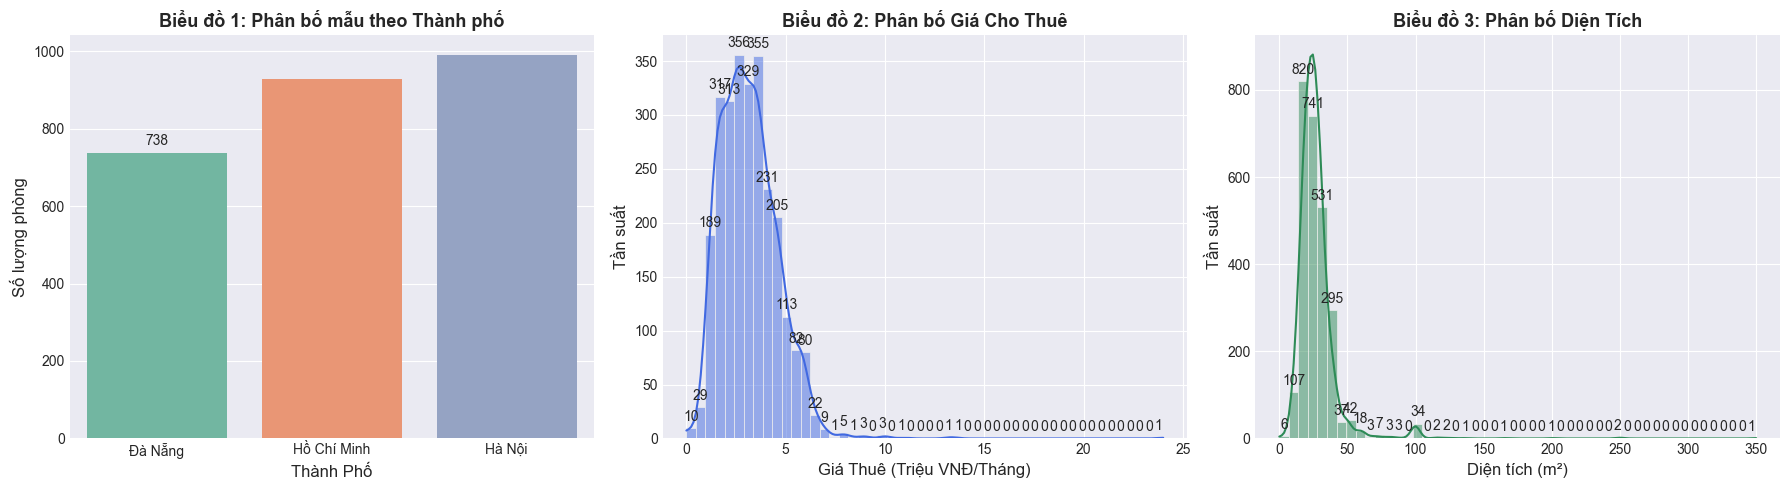

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập phong cách biểu đồ
plt.rcParams['font.family'] = 'sans-serif'
plt.style.use('seaborn-v0_8-darkgrid')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Figure 1: Số lượng phòng trọ theo thành phố
sns.countplot(x='Thành_Phố', data=df_raw, palette='Set2', ax=axes[0])
axes[0].set_title('Biểu đồ 1: Phân bố mẫu theo Thành phố', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Số lượng phòng')
axes[0].set_xlabel('Thành Phố')
axes[0].bar_label(axes[0].containers[0], padding=3) # Hiển thị số lượng cụ thể trên đỉnh cột

# Biểu đồ 2: Phân bố Giá cho thuê (Histogram + KDE)
sns.histplot(df_raw['Giá_Cho_Thuê'], bins=50, kde=True, color='royalblue', ax=axes[1])
axes[1].set_title('Biểu đồ 2: Phân bố Giá Cho Thuê', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Giá Thuê (Triệu VNĐ/Tháng)')
axes[1].set_ylabel('Tần suất')
axes[1].bar_label(axes[1].containers[0], padding=3) # Hiển thị số lượng cụ thể trên đỉnh cột

# Biểu đồ 3: Phân bố Diện tích (Histogram + KDE)
sns.histplot(df_raw['Diện_Tích_m2'], bins=50, kde=True, color='seagreen', ax=axes[2])
axes[2].set_title('Biểu đồ 3: Phân bố Diện Tích', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Diện tích (m²)')
axes[2].set_ylabel('Tần suất')
axes[2].bar_label(axes[2].containers[0], padding=3) # Hiển thị số lượng cụ thể trên đỉnh cột

plt.tight_layout()
plt.show()

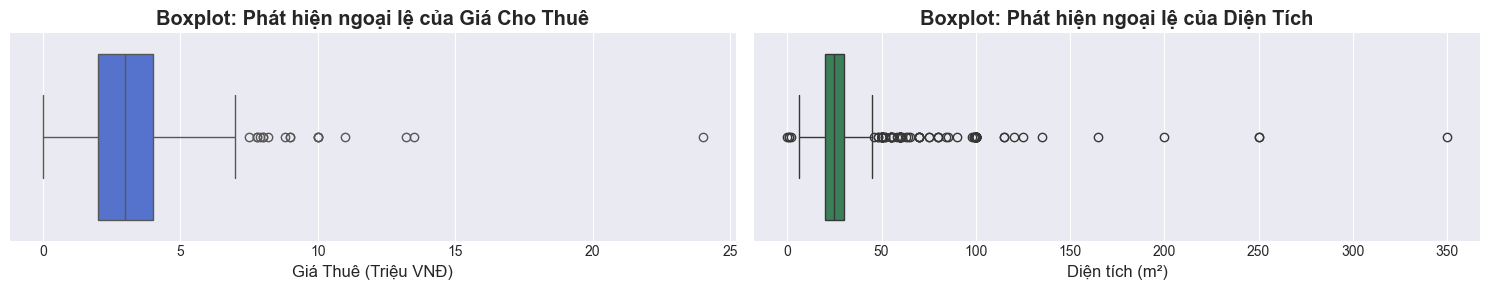

In [25]:
# Khởi tạo khung vẽ gồm 2 biểu đồ Boxplot
fig, axes = plt.subplots(1, 2, figsize=(15, 3))

# Boxplot cho Giá cho thuê
sns.boxplot(x=df_raw['Giá_Cho_Thuê'], color='royalblue', ax=axes[0])
axes[0].set_title('Boxplot: Phát hiện ngoại lệ của Giá Cho Thuê', fontweight='bold')
axes[0].set_xlabel('Giá Thuê (Triệu VNĐ)')

# Boxplot cho Diện tích
sns.boxplot(x=df_raw['Diện_Tích_m2'], color='seagreen', ax=axes[1])
axes[1].set_title('Boxplot: Phát hiện ngoại lệ của Diện Tích', fontweight='bold')
axes[1].set_xlabel('Diện tích (m²)')

plt.tight_layout()
plt.show()

**Nhận xét từ biểu đồ phân tích đơn biến:**

**1. Về phân bổ khu vực (Biều đồ 1):** Số lượng mẫu thu thập được phân bổ tương đối đồng đều ở các thành phố lớn (Hà Nội, TP.HCM, Đà Nẵng), đảm bảo tính đại diện cho mặt bằng chung của thị trường phòng trọ sinh viên.
**2. Về phân bố hình dáng (Biểu đồ 2 & 3):** 
- Cả hai biến `Giá_Cho_Thuê` và `Diện_Tích_m2` đều **không tuân theo phân phối chuẩn (Normal Distribution)**. Đường cong KDE cho thấy dữ liệu bị lệch phải rất nặng.
- Nguyên nhân: Phần lớn phòng trọ sinh viên tập trung ở phân khúc giá rẻ (2 - 5 triệu) và diện tích nhỏ (15 - 30 m2). Tuy nhiên, có một số lượng nhỏ các căn hộ dịch vụ cao cấp hoặc nhà nguyên căn, hoặc đơn giản là dữ liệu bị sai nên giá và diện tích kéo dài chiếc đuôi của đồ thị về phía bên phải.

**3. Về Ngoại lệ / Outlier:**
- Biểu đổ Boxplot xuât hiện rất nhiều điểm đen (outliers) nằm ngoài râu của đồ thị. Tồn tại các điểm dữ liệu bất hợp lý (Giá thuê = 0 đồng hoặc Diện tích 350 m2). Những dữ liệu rác này nếu đưa thẳng vào mô hình Hồi quy sẽ làm giảm độ chính xác và gây ra hiện tượng thiên kiến.

## 4. Làm sạch và Chuẩn hóa dữ liệu

### 4.1 Tiền xử lý dữ liệu (Data Preprocessing)
Dựa trên những phát hiện từ quá trình Khám phá dữ liệu, nhóm tiến hành tiền xử lý theo 3 bước tuần tự nhằm đảm bảo chất lượng dữ liệu tốt nhất trước khi đưa vào mô hình hóa:

**1. Trích xuất đặc trưng (Feature Engineering)**
- **Vấn đề:** Các tiện ích phòng trọ đang nằm dưới dạng văn bản phi cấu trúc tại cột `Mô_Tả`, `Nổi_Bật` và `Tiêu_Đề`.
- **Cách xử lý:** Sử dụng Biểu thức chính quy (Regex) để quét và bóc tách văn bản thành 10 biến tiện ích nhị phân (0/1). Sau đó, xóa bỏ các cột văn bản thô để tối ưu hóa bộ nhớ.

**2. Làm sạch dữ liệu ngoại lệ (Outlier)**
- **Vấn đề:** Biểu đồ Boxplot trước đó cho thấy sự xuất hiện của các điểm dữ liệu nhiễu (Giá = 0 đồng) và các ngoại lệ quá lớn (Nhà nguyên căn, căn hộ dịch vụ bị nhầm lẫn vào dữ liệu phòng trọ sinh viên hoặc bị nhầm lẫn khi nhập liệu).
- **Cách xử lý:** Quyết định chỉ giữ lại các phòng trọ có `Giá từ 0.5 - 7 triệu/tháng` và `Diện tích từ 8 - 50 m2`. 

**3. Chuẩn hóa dữ liệu**
- **Vấn đề:** Biểu đồ Histogram cho thấy phân bố của Giá và Diện tích bị **lệch phải nghiêm trọng**, vi phạm giả định phân phối chuẩn của mô hình hồi quy tuyến tính.
- **Cách xử lý:** Áp dụng phép biến đổi logarit tự nhiên `np.log1p()` để co hẹp khoảng cách của các giá trị lớn, kéo phân phối của dữ liệu về sát với dạng hình quả chuông (Normal Distribution).

### Trích xuất đặc trưng (Feature Engineering) và Xóa Outliers

In [4]:
import re
import numpy as np

In [9]:
# Xử lý Missing Values ở các cột văn bản bằng cách điền chuỗi rỗng
df_raw['Tiêu_Đề'] = df_raw['Tiêu_Đề'].fillna('')
df_raw['Mô_Tả'] = df_raw['Mô_Tả'].fillna('')
df_raw['Nổi_Bật'] = df_raw['Nổi_Bật'].fillna('')

# Gộp các cột văn bản thành một cột duy nhất để không bị sót thông tin
df_raw['Full_Text'] = df_raw['Tiêu_Đề'] + ' ' + df_raw['Mô_Tả'] + ' ' + df_raw['Nổi_Bật']

In [7]:
# Hàm bóc tách dựa trên Regex 
def extract_utilities(text_content):
    d = str(text_content).lower()
    return pd.Series({
        "Máy_Lạnh": 1 if re.search(r'(máy lạnh|điều hòa|điều hoà)', d) else 0,
        "Nóng_Lạnh": 1 if re.search(r'(nóng lạnh|máy nước nóng|bình nước nóng)', d) else 0,
        "Thang_Máy": 1 if re.search(r'(thang máy)', d) else 0,
        "Tủ_Lạnh": 1 if re.search(r'(tủ lạnh)', d) else 0,
        "Máy_Giặt": 1 if re.search(r'(máy giặt)', d) else 0,
        "Đầy_Đủ_Nội_Thất": 1 if re.search(r'(đầy đủ nội thất|full nội thất|nội thất đầy đủ)', d) else 0,
        "Có_Gác_Lửng": 1 if re.search(r'(có gác|gác lửng|gác xép)', d) else 0,
        "Bảo_Vệ_An_Ninh": 1 if re.search(r'(bảo vệ|an ninh|camera)', d) else 0,
        "Giờ_Tự_Do": 1 if re.search(r'(giờ giấc tự do|giờ tự do|chìa khóa trao tay|giờ giấc thoải mái)', d) else 0,
        "Không_Chung_Chủ": 1 if re.search(r'(không chung chủ|lối đi riêng)', d) else 0
    })

In [10]:
features_df = df_raw['Full_Text'].apply(extract_utilities)
df_clean = pd.concat([df_raw, features_df], axis=1)

In [11]:
# Xóa bỏ các cột văn bản và cột định danh không cần thiết
cols_to_drop = ['Mã_Tin', 'Thời_Gian_Đăng', 'Tiêu_Đề', 'Mô_Tả', 'Nổi_Bật', 'Full_Text']
cols_to_drop = [c for c in cols_to_drop if c in df_clean.columns]
df_clean = df_clean.drop(columns=cols_to_drop)

print(f"Kích thước sau Feature Engineering: {df_clean.shape[0]} mẫu, {df_clean.shape[1]} biến.")

df_clean = df_clean[(df_clean['Giá_Cho_Thuê'] >= 0.5) & (df_clean['Giá_Cho_Thuê'] <= 7)]
df_clean = df_clean[(df_clean['Diện_Tích_m2'] >= 8) & (df_clean['Diện_Tích_m2'] <= 50)]

print(f"Kích thước sau khi Outliers: {df_clean.shape[0]} mẫu, {df_clean.shape[1]} biến.")

Kích thước sau Feature Engineering: 2657 mẫu, 14 biến.
Kích thước sau khi Outliers: 2542 mẫu, 14 biến.


### Chuẩn hóa logarit & Trực quan hóa so sánh

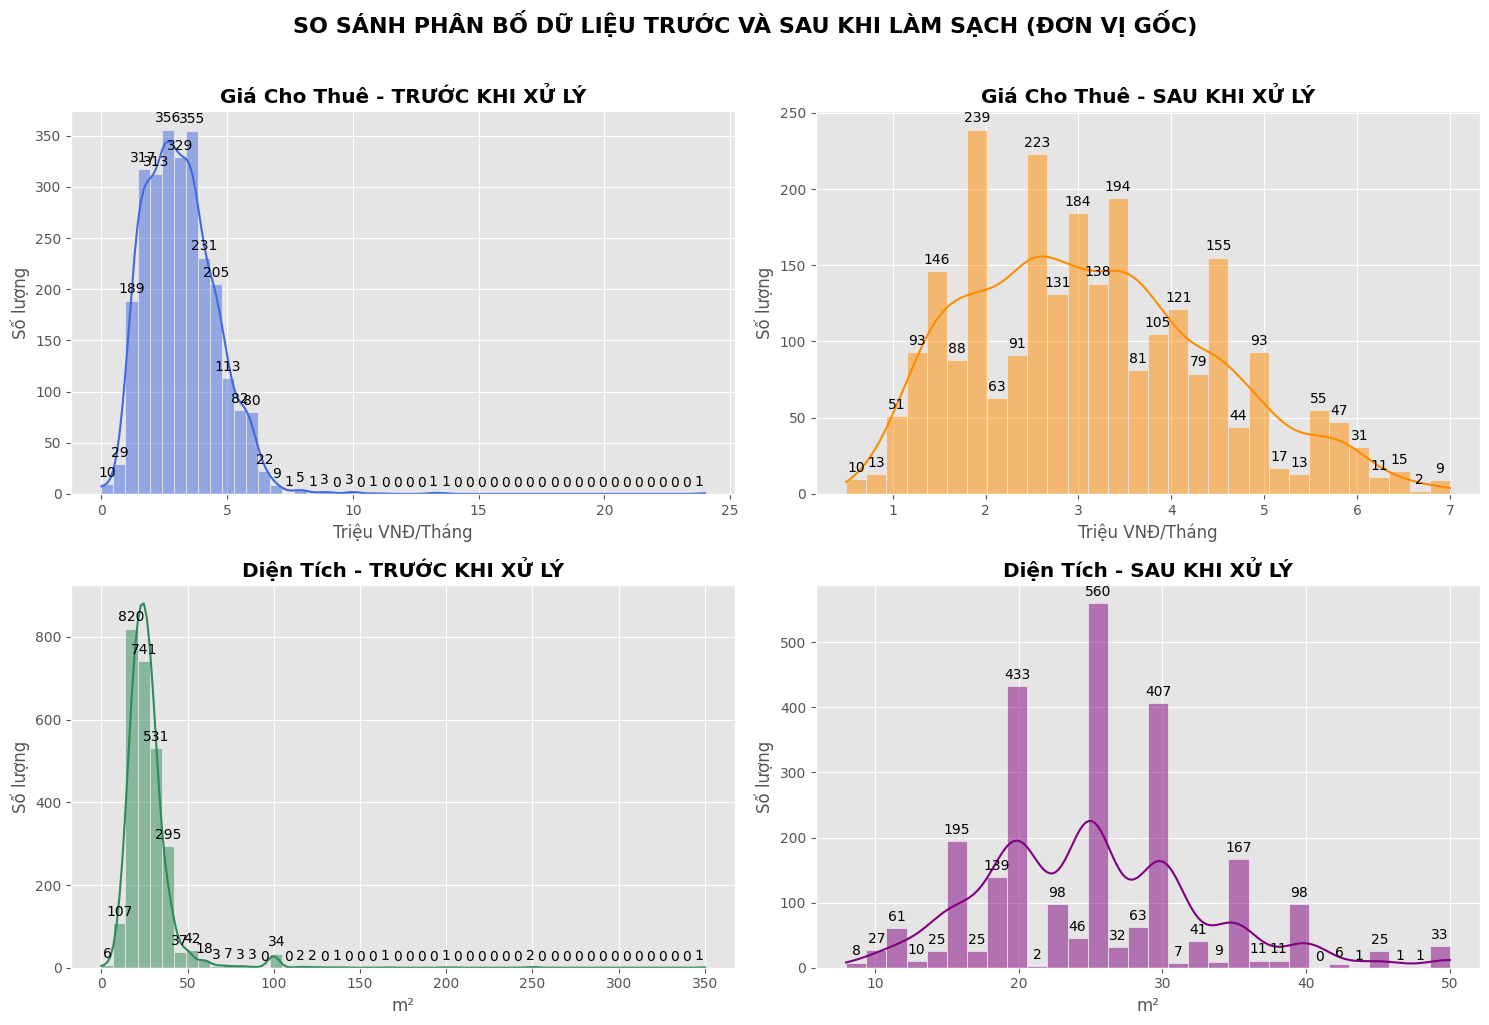

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# So sánh phân bố dữ liệu trước và sau khi làm sạch bằng biểu đồ histogram kết hợp KDE
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('SO SÁNH PHÂN BỐ DỮ LIỆU TRƯỚC VÀ SAU KHI LÀM SẠCH (ĐƠN VỊ GỐC)', fontsize=16, fontweight='bold', y=1.02)

# --- HÀNG 1: GIÁ CHO THUÊ ---
sns.histplot(df_raw['Giá_Cho_Thuê'], bins=50, kde=True, color='royalblue', ax=axes[0, 0])
axes[0, 0].set_title('Giá Cho Thuê - TRƯỚC KHI XỬ LÝ', fontweight='bold')
axes[0, 0].set_xlabel('Triệu VNĐ/Tháng')
axes[0, 0].set_ylabel('Số lượng')
axes[0, 0].bar_label(axes[0, 0].containers[0], padding=3) # Hiển thị số lượng cụ thể trên đỉnh cột

sns.histplot(df_clean['Giá_Cho_Thuê'], bins=30, kde=True, color='darkorange', ax=axes[0, 1])
axes[0, 1].set_title('Giá Cho Thuê - SAU KHI XỬ LÝ', fontweight='bold')
axes[0, 1].set_xlabel('Triệu VNĐ/Tháng')
axes[0, 1].set_ylabel('Số lượng')
axes[0, 1].bar_label(axes[0, 1].containers[0], padding=3) # Hiển thị số lượng cụ thể trên đỉnh cột

# --- HÀNG 2: DIỆN TÍCH ---
sns.histplot(df_raw['Diện_Tích_m2'], bins=50, kde=True, color='seagreen', ax=axes[1, 0])
axes[1, 0].set_title('Diện Tích - TRƯỚC KHI XỬ LÝ', fontweight='bold')
axes[1, 0].set_xlabel('m²')
axes[1, 0].set_ylabel('Số lượng')
axes[1, 0].bar_label(axes[1, 0].containers[0], padding=3) # Hiển thị số lượng cụ thể trên đỉnh cột

sns.histplot(df_clean['Diện_Tích_m2'], bins=30, kde=True, color='purple', ax=axes[1, 1])
axes[1, 1].set_title('Diện Tích - SAU KHI XỬ LÝ', fontweight='bold')
axes[1, 1].set_xlabel('m²')
axes[1, 1].set_ylabel('Số lượng')
axes[1, 1].bar_label(axes[1, 1].containers[0], padding=3) # Hiển thị số lượng cụ thể trên đỉnh cột


plt.tight_layout()
plt.show()

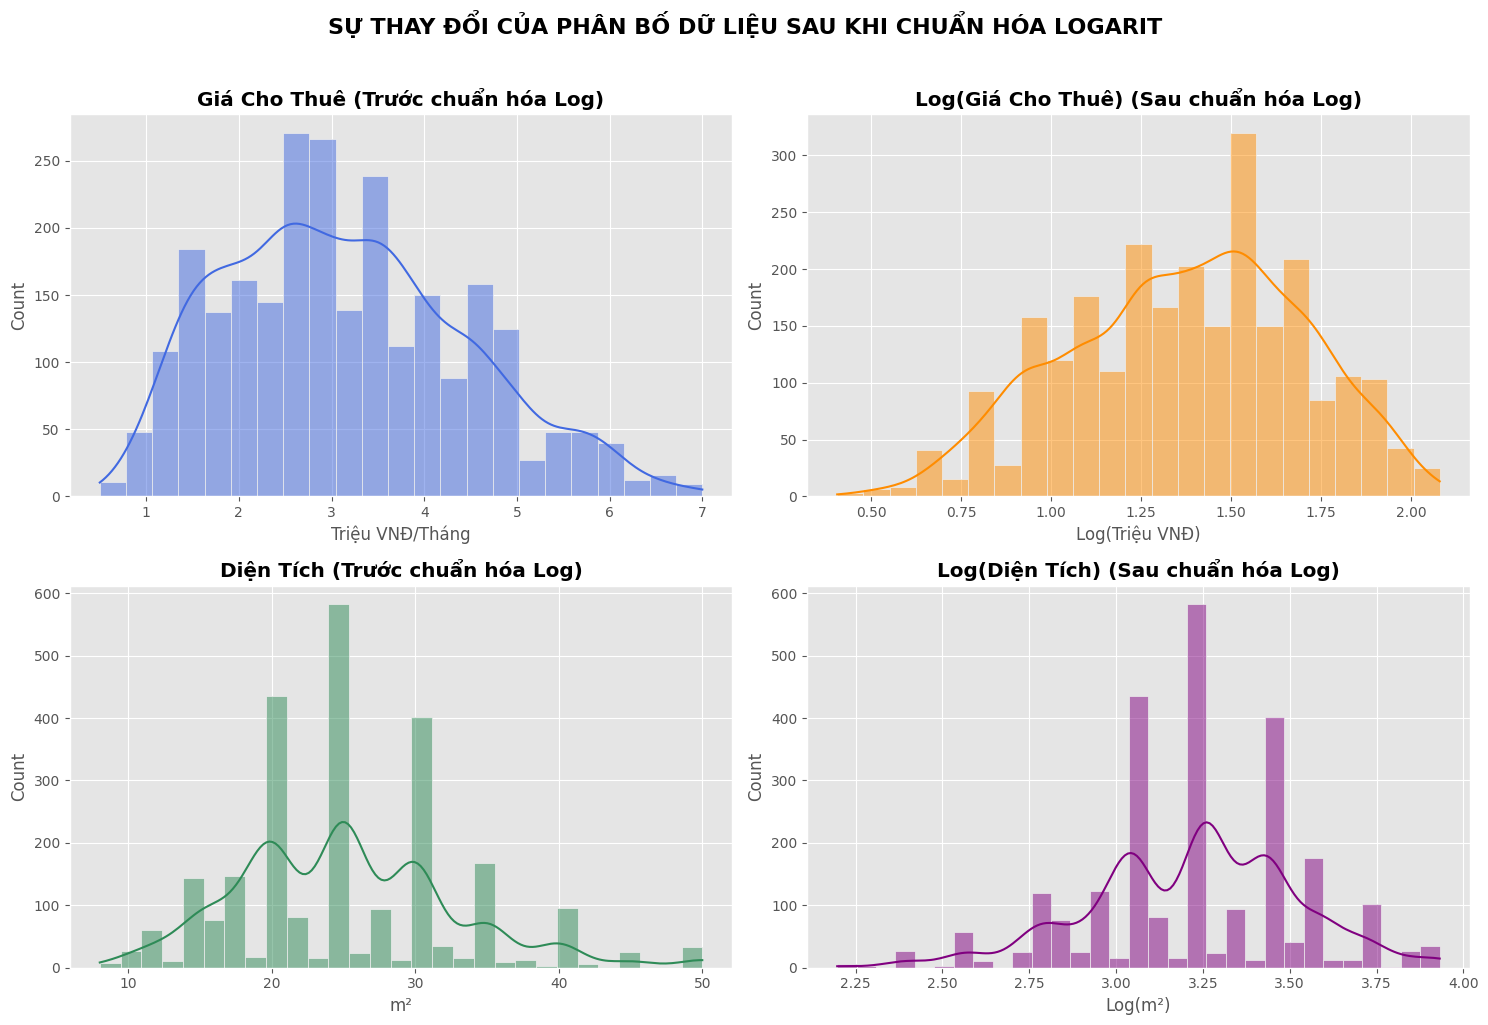

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Áp dụng hàm log1p (Logarit tự nhiên của 1 + x)
df_clean['Log_Giá'] = np.log1p(df_clean['Giá_Cho_Thuê'])
df_clean['Log_Diện_Tích'] = np.log1p(df_clean['Diện_Tích_m2'])

# VẼ BIỂU ĐỒ SO SÁNH TRƯỚC VÀ SAU KHI CHUẨN HÓA
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('SỰ THAY ĐỔI CỦA PHÂN BỐ DỮ LIỆU SAU KHI CHUẨN HÓA LOGARIT', fontsize=16, fontweight='bold', y=1.02)

# --- Hàng 1: Giá Cho Thuê ---
sns.histplot(df_clean['Giá_Cho_Thuê'], kde=True, color='royalblue', ax=axes[0, 0])
axes[0, 0].set_title('Giá Cho Thuê (Trước chuẩn hóa Log)', fontweight='bold')
axes[0, 0].set_xlabel('Triệu VNĐ/Tháng')

sns.histplot(df_clean['Log_Giá'], kde=True, color='darkorange', ax=axes[0, 1])
axes[0, 1].set_title('Log(Giá Cho Thuê) (Sau chuẩn hóa Log)', fontweight='bold')
axes[0, 1].set_xlabel('Log(Triệu VNĐ)')

# --- Hàng 2: Diện Tích ---
sns.histplot(df_clean['Diện_Tích_m2'], kde=True, color='seagreen', ax=axes[1, 0])
axes[1, 0].set_title('Diện Tích (Trước chuẩn hóa Log)', fontweight='bold')
axes[1, 0].set_xlabel('m²')

sns.histplot(df_clean['Log_Diện_Tích'], kde=True, color='purple', ax=axes[1, 1])
axes[1, 1].set_title('Log(Diện Tích) (Sau chuẩn hóa Log)', fontweight='bold')
axes[1, 1].set_xlabel('Log(m²)')

plt.tight_layout()
plt.show()

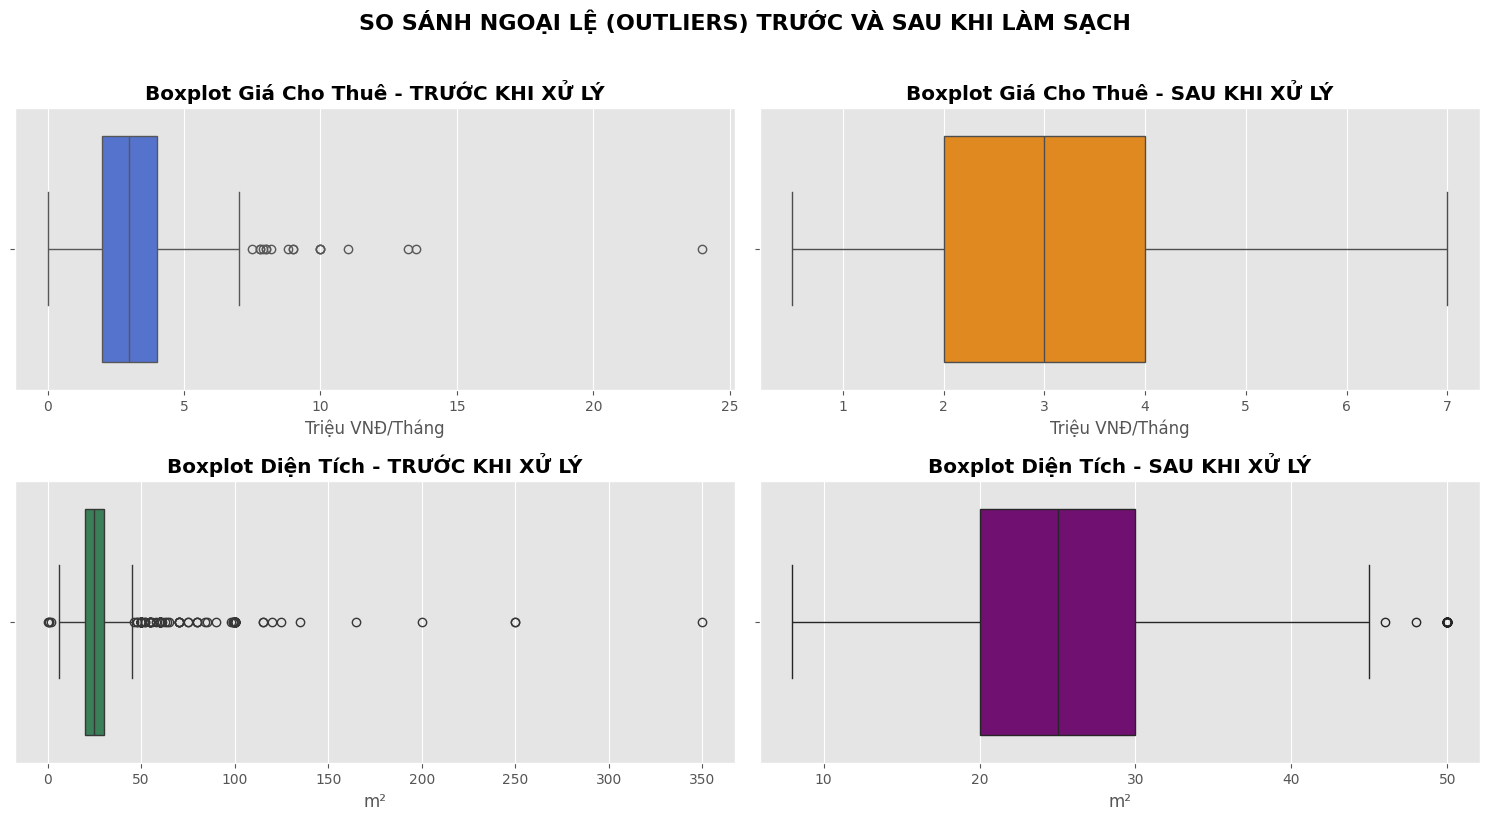

In [19]:
# So sánh ngoại lệ bằng Boxplot trước và sau khi làm sạch dữ liệu
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
fig.suptitle('SO SÁNH NGOẠI LỆ (OUTLIERS) TRƯỚC VÀ SAU KHI LÀM SẠCH', fontsize=16, fontweight='bold', y=1.02)

# Hàng 1: Giá cho thuê
sns.boxplot(x=df_raw['Giá_Cho_Thuê'], color='royalblue', ax=axes[0, 0])
axes[0, 0].set_title('Boxplot Giá Cho Thuê - TRƯỚC KHI XỬ LÝ', fontweight='bold')
axes[0, 0].set_xlabel('Triệu VNĐ/Tháng')

sns.boxplot(x=df_clean['Giá_Cho_Thuê'], color='darkorange', ax=axes[0, 1])
axes[0, 1].set_title('Boxplot Giá Cho Thuê - SAU KHI XỬ LÝ', fontweight='bold')
axes[0, 1].set_xlabel('Triệu VNĐ/Tháng')

# Hàng 2: Diện tích
sns.boxplot(x=df_raw['Diện_Tích_m2'], color='seagreen', ax=axes[1, 0])
axes[1, 0].set_title('Boxplot Diện Tích - TRƯỚC KHI XỬ LÝ', fontweight='bold')
axes[1, 0].set_xlabel('m²')

sns.boxplot(x=df_clean['Diện_Tích_m2'], color='purple', ax=axes[1, 1])
axes[1, 1].set_title('Boxplot Diện Tích - SAU KHI XỬ LÝ', fontweight='bold')
axes[1, 1].set_xlabel('m²')

plt.tight_layout()
plt.show()

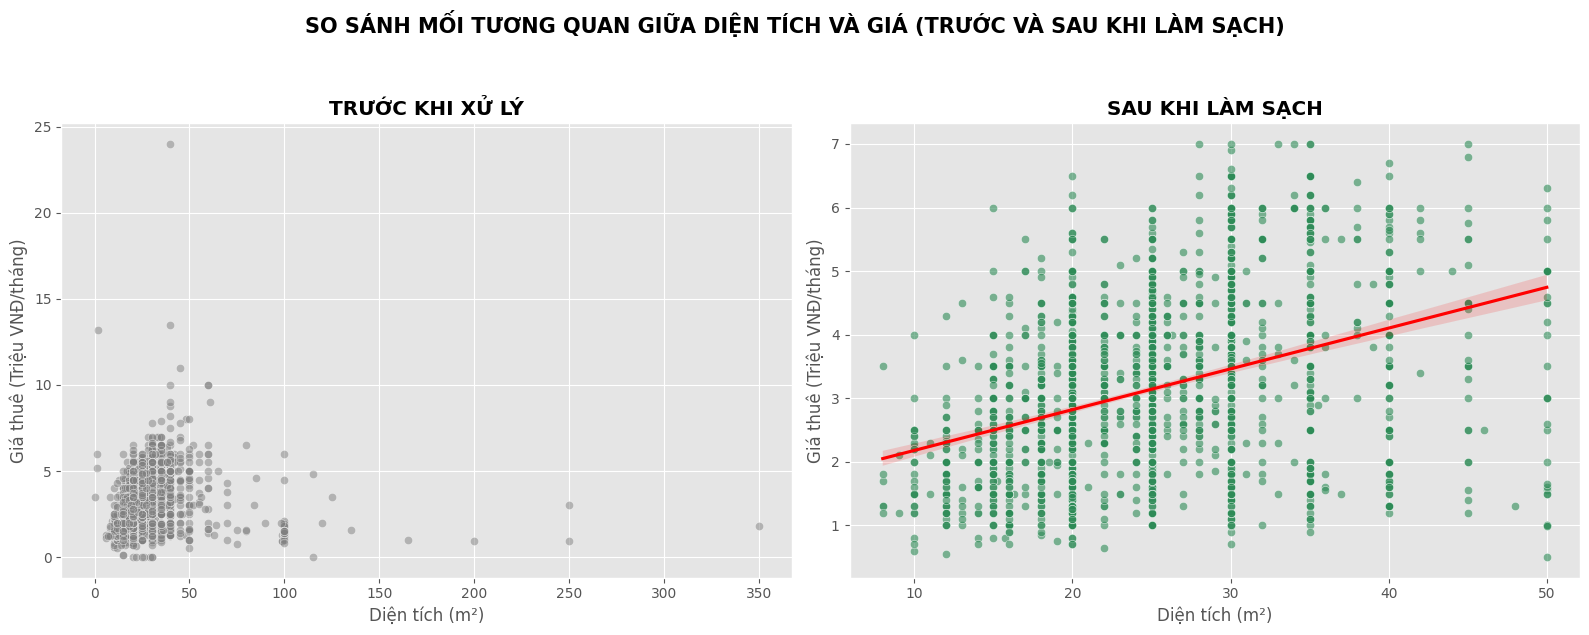

In [56]:
# So sánh mối quan hệ tương quan giữa Diện tích và Giá cho thuê trước và sau khi làm sạch dữ liệu
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('SO SÁNH MỐI TƯƠNG QUAN GIỮA DIỆN TÍCH VÀ GIÁ (TRƯỚC VÀ SAU KHI LÀM SẠCH)', fontsize=15, fontweight='bold', y=1.05)

# 1. Trước khi xử lý (df_raw)
sns.scatterplot(x='Diện_Tích_m2', y='Giá_Cho_Thuê', data=df_raw, alpha=0.5, color='gray', ax=axes[0])
axes[0].set_title('TRƯỚC KHI XỬ LÝ', fontweight='bold')
axes[0].set_xlabel('Diện tích (m²)')
axes[0].set_ylabel('Giá thuê (Triệu VNĐ/tháng)')

# 2. Sau khi xử lý (df_clean)
sns.scatterplot(x='Diện_Tích_m2', y='Giá_Cho_Thuê', data=df_clean, alpha=0.6, color='seagreen', ax=axes[1])
sns.regplot(x='Diện_Tích_m2', y='Giá_Cho_Thuê', data=df_clean, scatter=False, color='red', ax=axes[1])
axes[1].set_title('SAU KHI LÀM SẠCH', fontweight='bold')
axes[1].set_xlabel('Diện tích (m²)')
axes[1].set_ylabel('Giá thuê (Triệu VNĐ/tháng)')

plt.tight_layout()
plt.show()

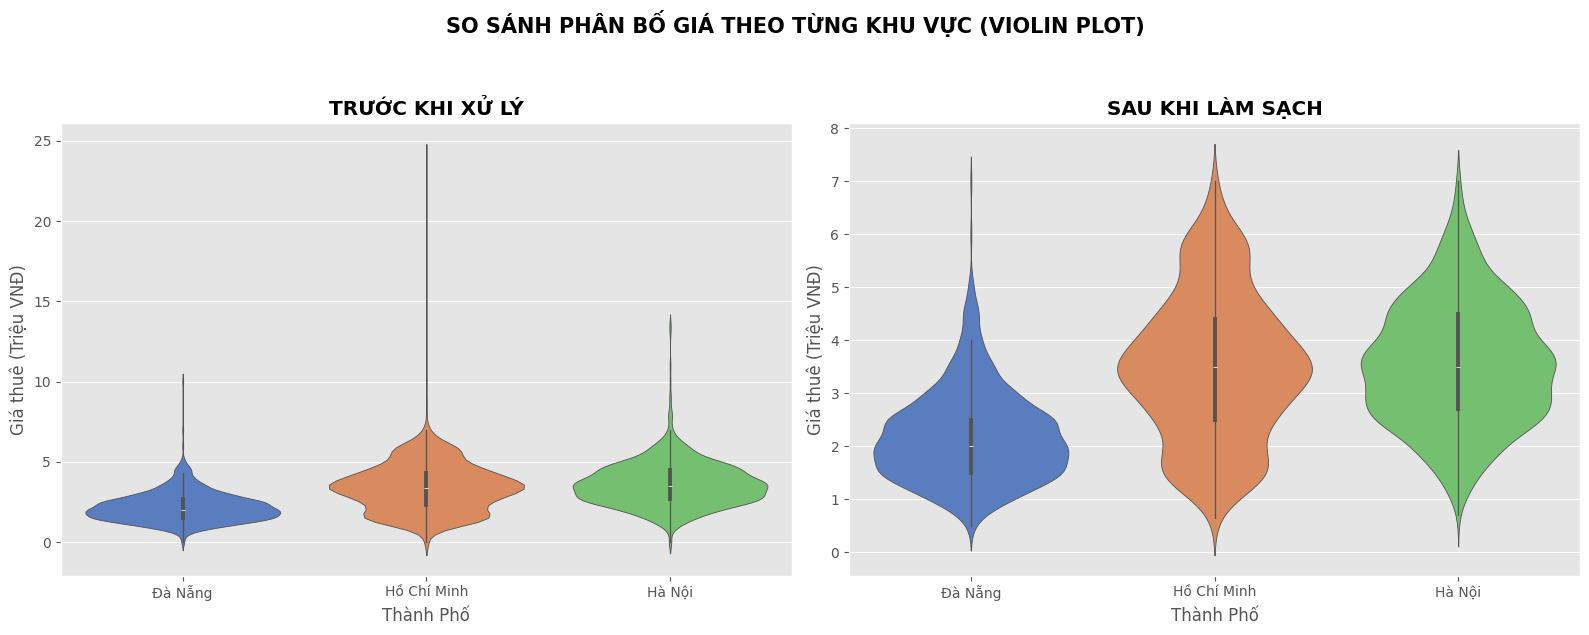

In [57]:
# So sánh phân bố theo thành phố bằng violin plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('SO SÁNH PHÂN BỐ GIÁ THEO TỪNG KHU VỰC (VIOLIN PLOT)', fontsize=15, fontweight='bold', y=1.05)

# 1. Trước khi xử lý
sns.violinplot(x='Thành_Phố', y='Giá_Cho_Thuê', data=df_raw, palette='muted', ax=axes[0])
axes[0].set_title('TRƯỚC KHI XỬ LÝ', fontweight='bold')
axes[0].set_xlabel('Thành Phố')
axes[0].set_ylabel('Giá thuê (Triệu VNĐ)')

# 2. Sau khi xử lý
sns.violinplot(x='Thành_Phố', y='Giá_Cho_Thuê', data=df_clean, palette='muted', ax=axes[1])
axes[1].set_title('SAU KHI LÀM SẠCH', fontweight='bold')
axes[1].set_xlabel('Thành Phố')
axes[1].set_ylabel('Giá thuê (Triệu VNĐ)')

plt.tight_layout()
plt.show()

## Phân tích tác động của các Tiện ích đến Giá cho thuê phòng trọ

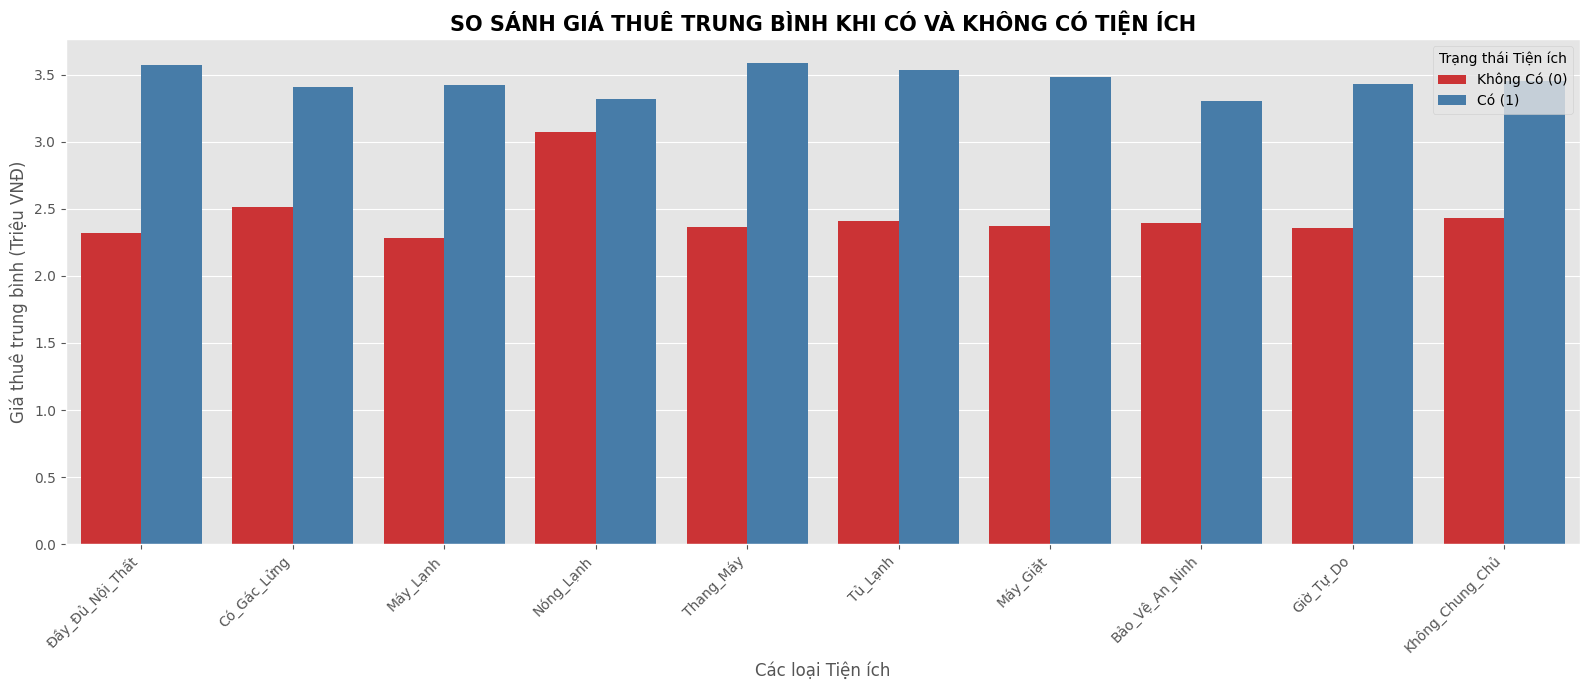

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Danh sách 10 cột tiện ích
utility_cols = ['Đầy_Đủ_Nội_Thất', 'Có_Gác_Lửng', 'Máy_Lạnh', 'Nóng_Lạnh', 
                'Thang_Máy', 'Tủ_Lạnh', 'Máy_Giặt', 'Bảo_Vệ_An_Ninh', 'Giờ_Tự_Do', 'Không_Chung_Chủ']

# Tạo một bảng Dataframe mới để tính giá trung bình
utility_price_data = []

for col in utility_cols:
    # Giá trung bình khi Không có tiện ích (0)
    price_0 = df_clean[df_clean[col] == 0]['Giá_Cho_Thuê'].mean()
    # Giá trung bình khi Có tiện ích (1)
    price_1 = df_clean[df_clean[col] == 1]['Giá_Cho_Thuê'].mean()
    
    utility_price_data.append({'Tiện_Ích': col, 'Trạng_Thái': 'Không Có (0)', 'Giá_Trung_Bình': price_0})
    utility_price_data.append({'Tiện_Ích': col, 'Trạng_Thái': 'Có (1)', 'Giá_Trung_Bình': price_1})

df_utility_price = pd.DataFrame(utility_price_data)

# Vẽ biểu đồ
plt.figure(figsize=(16, 7))
sns.barplot(x='Tiện_Ích', y='Giá_Trung_Bình', hue='Trạng_Thái', data=df_utility_price, palette='Set1')

plt.title('SO SÁNH GIÁ THUÊ TRUNG BÌNH KHI CÓ VÀ KHÔNG CÓ TIỆN ÍCH', fontsize=15, fontweight='bold')
plt.xlabel('Các loại Tiện ích')
plt.ylabel('Giá thuê trung bình (Triệu VNĐ)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Trạng thái Tiện ích')
plt.tight_layout()
plt.show()

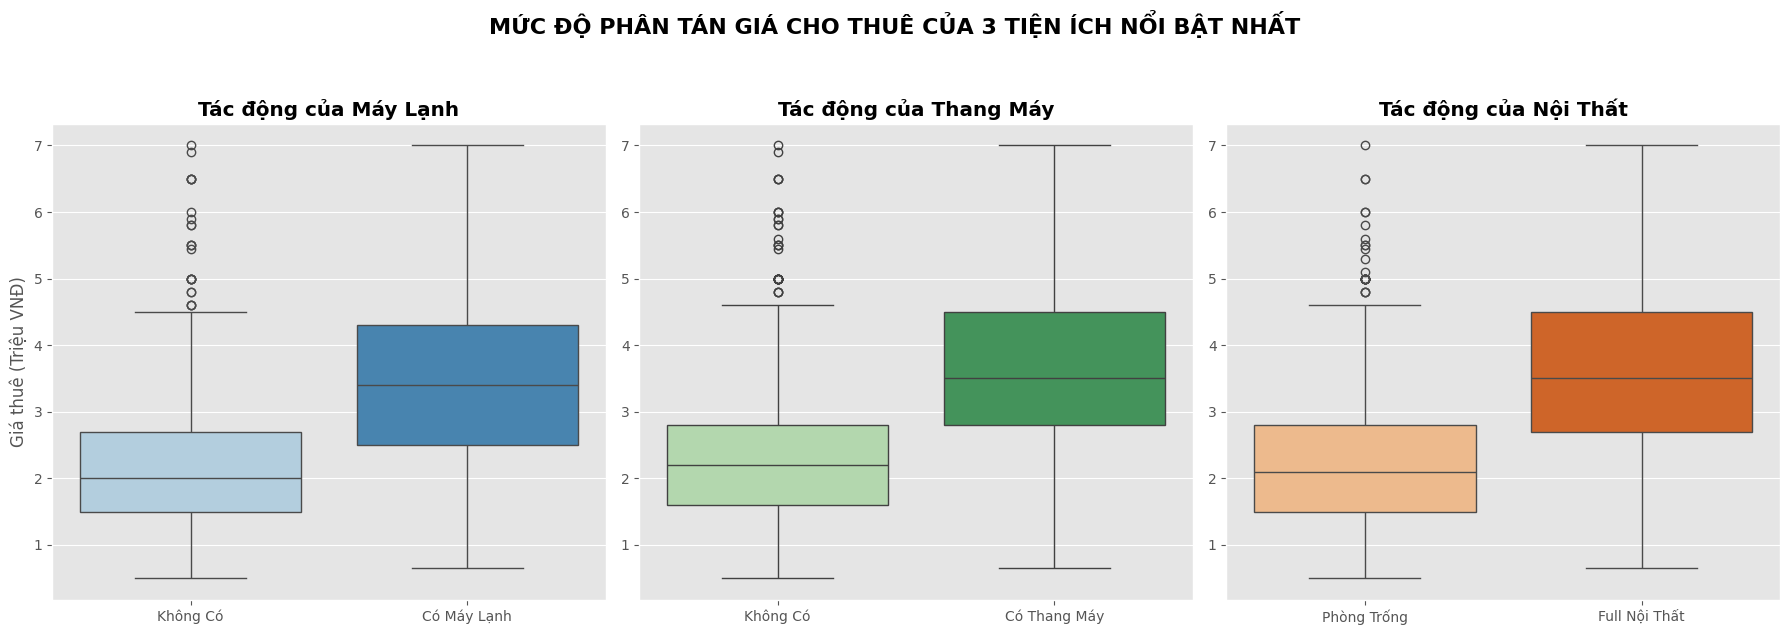

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('MỨC ĐỘ PHÂN TÁN GIÁ CHO THUÊ CỦA 3 TIỆN ÍCH NỔI BẬT NHẤT', fontsize=16, fontweight='bold', y=1.05)

# 1. Máy Lạnh
sns.boxplot(x='Máy_Lạnh', y='Giá_Cho_Thuê', data=df_clean, palette='Blues', ax=axes[0])
axes[0].set_title('Tác động của Máy Lạnh', fontweight='bold')
axes[0].set_xticklabels(['Không Có', 'Có Máy Lạnh'])
axes[0].set_ylabel('Giá thuê (Triệu VNĐ)')
axes[0].set_xlabel('')

# 2. Thang Máy
sns.boxplot(x='Thang_Máy', y='Giá_Cho_Thuê', data=df_clean, palette='Greens', ax=axes[1])
axes[1].set_title('Tác động của Thang Máy', fontweight='bold')
axes[1].set_xticklabels(['Không Có', 'Có Thang Máy'])
axes[1].set_ylabel('')
axes[1].set_xlabel('')

# 3. Đầy Đủ Nội Thất
sns.boxplot(x='Đầy_Đủ_Nội_Thất', y='Giá_Cho_Thuê', data=df_clean, palette='Oranges', ax=axes[2])
axes[2].set_title('Tác động của Nội Thất', fontweight='bold')
axes[2].set_xticklabels(['Phòng Trống', 'Full Nội Thất'])
axes[2].set_ylabel('')
axes[2].set_xlabel('')

plt.tight_layout()
plt.show()

### Nhận xét và đánh giá sau khi làm sạch và chuẩn hóa dữ liệu:
Thông qua các biểu đồ so sánh trực quan giữa dữ liệu gốc (Raw Data) và dữ liệu sau khi làm sạch (Clean Data), rút ra những nhận xét sau:

**1. Về sự thay đổi của Phân phối (Đồ thị Histogram)**
- Trước khi làm sạch, đồ thị bị bóp mém - bởi các giá trị dị biệt (phòng có giá 24 triệu/tháng, rộng 350 m2).
- Sau khi loại bỏ ngoại lệ (giữ mức 0.5 - 7 triệu và 8 - 50 m2), dữ liệu đã tập trung vào đúng phân khúc phòng trọ sinh viên.
- **Tác dụng của chuẩn hóa Logarit:** Khi áp dụng phép biến đổi Logarit (`Log_Giá` và `Log_Diện_Tích`), đồ thị từ trạng thái Lệch phải đã được kéo về trạng thái cân xứng hình quả chuông (Phân phối chuẩn).

**2. Về sự rõ nét của xu hướng tuyến tính (Đồ thị Scatter Plot)**
- Biểu đồ phân tán minh chứng cho hiệu quả của việc cắt xén. Ở dữ liệu gốc, các điểm Outlier làm mờ đi quy luật của tập dữ liệu.
- Trong khi đó, ở đồ thị Clean Data, một **đường xu hướng tuyến tính đồng biến** hiện ra rõ rệt: Diện tích tỉ lệ thuận với Giá thuê. Các điểm dữ liệu bám khá sát xung quanh đường xu hướng này.

**3. Về cấu trúc giá theo khu vực (Đồ thị Violin Plot)**
- Đồ thị vĩ cầm của tập dữ liệu sạch cho thấy bức tranh thị trường rõ rệt.
- **Đà Nẵng**: Phần bụng vĩ cầm phình to ở mốc giá thấp (2 - 3 triệu) và thuôn nhọn rất nhanh, chứng tỏ mặt bằng giá ở đây rẻ và ít sự phân hóa.
- **Hà Nội & TP.HCM**: Phân thân vĩ cầm kéo dài và trải rộng ở mốc từ 3 - 5 triệu, cho thấy mức giá cao hơn và thị trường có rất nhiều phân khúc đa dạng.

**4. Về tác động của Tiện ích**
- **Từ biểu đồ cột:** 
    + Hầu hết mọ tiện ích đều làm tăng giá trị của căn phòng. Các cột màu đỏ (Có tiện ích) luôn cao hơn cột màu xanh (Không có tiện ích).
    + Tuy nhiên, mức độ tác động không đồng đều. Các tiện ích cốt lõi thuộc về cấu trúc và đầu tư lớn như: **Thang_Máy**, **Nóng_Lạnh**, **Đầy_Đủ_Nội_Thất** tạo ra khoảng chênh lệch giá lớn nhất.
    + Ngược lại, những tiện ích mang tính quy định như **Giờ_Tự_Do**, **Không_Chung_Chủ**, **Có_Gác_Lửng** ít tạo ra sự đột biến về giá vì chúng thường là tiêu chuẩn chung của các phòng trọ sinh viên hiện nay.

- **Từ biểu đồ Boxplot (Top 3 tiện ích)**
    + Sự khác biệt về mặt bằng giá cực kỳ rõ ràng. Với các phòng không có Thang máy hoặc không có Máy lạnh, đồ thị Boxplot bị ép xuống rất thấp, mức quá kịch trần thường không vượt quá 3-4 triệu.
    + Khi được trang bị Full nội thất hoặc Thang máy, không chỉ mức giá trung bình (đường kẻ ngang trong hộp) tăng lên, mà toàn bộ dải phân bố giá cũng được kéo dài lên phân khúc 4 - 7 triệu.

### Xuất file Dữ liệu sạch (Clean Data)

In [58]:
first_cols = ['Thành_Phố', 'Quận_Huyện', 'Giá_Cho_Thuê', 'Log_Giá', 'Diện_Tích_m2', 'Log_Diện_Tích']
utility_cols = [c for c in df_clean.columns if c not in first_cols]

final_cols = first_cols + utility_cols
df_clean = df_clean[final_cols]

# Export data after cleaning
file_clean_path = '../data_phongtro/clean_data.csv'
df_clean.to_csv(file_clean_path, index=False, encoding='utf-8-sig')

print(f"Lưu thành công dữ liệu sạch vào: {file_clean_path} với {df_clean.shape[0]} mẫu và {df_clean.shape[1]} biến.")

Lưu thành công dữ liệu sạch vào: ../data_phongtro/clean_data.csv với 2542 mẫu và 16 biến.


### Lấy ra 5 dòng đầu tiên của file sau khi đã làm sạch

In [60]:
display(df_clean.head(5))

,Thành_Phố,Quận_Huyện,Giá_Cho_Thuê,Log_Giá,Diện_Tích_m2,Log_Diện_Tích,Máy_Lạnh,Nóng_Lạnh,Thang_Máy,Tủ_Lạnh,Máy_Giặt,Đầy_Đủ_Nội_Thất,Có_Gác_Lửng,Bảo_Vệ_An_Ninh,Giờ_Tự_Do,Không_Chung_Chủ
0,Đà Nẵng,Liên Chiểu,2.7,1.308333,18.0,2.944439,1,0,1,1,1,1,1,1,1,1
1,Đà Nẵng,Hải Châu,4.0,1.609438,30.0,3.433987,1,0,1,1,1,1,1,1,1,1
2,Đà Nẵng,Hải Châu,1.7,0.993252,18.0,2.944439,0,0,0,0,0,0,0,0,0,0
3,Đà Nẵng,Cẩm Lệ,3.3,1.458615,20.0,3.044522,1,0,1,1,1,1,1,1,1,1
4,Đà Nẵng,Ngũ Hành Sơn,2.0,1.098612,20.0,3.044522,1,0,1,1,1,1,1,1,1,1


In [61]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 2542 entries, 0 to 2656
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Thành_Phố        2542 non-null   str    
 1   Quận_Huyện       2542 non-null   str    
 2   Giá_Cho_Thuê     2542 non-null   float64
 3   Log_Giá          2542 non-null   float64
 4   Diện_Tích_m2     2542 non-null   float64
 5   Log_Diện_Tích    2542 non-null   float64
 6   Máy_Lạnh         2542 non-null   int64  
 7   Nóng_Lạnh        2542 non-null   int64  
 8   Thang_Máy        2542 non-null   int64  
 9   Tủ_Lạnh          2542 non-null   int64  
 10  Máy_Giặt         2542 non-null   int64  
 11  Đầy_Đủ_Nội_Thất  2542 non-null   int64  
 12  Có_Gác_Lửng      2542 non-null   int64  
 13  Bảo_Vệ_An_Ninh   2542 non-null   int64  
 14  Giờ_Tự_Do        2542 non-null   int64  
 15  Không_Chung_Chủ  2542 non-null   int64  
dtypes: float64(4), int64(10), str(2)
memory usage: 337.6 KB


In [63]:
df_clean.describe().round(2)

,Giá_Cho_Thuê,Log_Giá,Diện_Tích_m2,Log_Diện_Tích,Máy_Lạnh,Nóng_Lạnh,Thang_Máy,Tủ_Lạnh,Máy_Giặt,Đầy_Đủ_Nội_Thất,Có_Gác_Lửng,Bảo_Vệ_An_Ninh,Giờ_Tự_Do,Không_Chung_Chủ
count,2542.00,2542.00,2542.00,2542.00,2542.00,2542.00,2542.00,2542.00,2542.00,2542.00,2542.00,2542.00,2542.00,2542.00
mean,3.15,1.37,25.14,3.22,0.76,0.31,0.64,0.66,0.70,0.66,0.71,0.83,0.74,0.70
std,1.31,0.32,7.70,0.30,0.43,0.46,0.48,0.47,0.46,0.47,0.46,0.37,0.44,0.46
min,0.50,0.41,8.00,2.20,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2.00,1.10,20.00,3.04,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
50%,3.00,1.39,25.00,3.26,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
75%,4.00,1.61,30.00,3.43,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
max,7.00,2.08,50.00,3.93,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


## 5. Mã hóa biến danh mục


**5.1 Vector hóa Tiện ích bằng Regex (Multi-Hot Encoding):**
- **Vấn đề:** Các tiện ích phòng trọ đang nằm dưới dạng văn bản phi cấu trúc tại cột `Mô_Tả`, `Nổi_Bật`. Nên ta cần phải trích xuất và mã hóa chúng thành các biến nhị phân (0/1) để máy tính có thể hiểu và sử dụng trong mô hình hóa. 
- **Cách xử lý:** Tương tự như One-Hot Encoding, nhưng ở đây là Multi-Hot Encoding vì một phòng trọ có thể có nhiều tiện ích cùng lúc. Sử dụng biểu thức chính quy (Regex) để tìm kiếm các từ khóa liên quan đến từng tiện ích trong cột văn bản, sau đó tạo ra các cột mới tương ứng với mỗi tiện ích, gán giá trị 1 nếu có tiện ích đó và 0 nếu không.

**5.2. Mã hóa Vị trí bằng Target Encoding:**
- **Vấn đề:** Thay vì gán số định danh cho các thành phố và quận huyện, nên đã thay thế tên `Thành_Phố` và `Quận_Huyện` bằng chính **Giá thuê trung bình** của khu vực đó.
- **Tác dụng:** Giúp biến vị trí trở thành một biến định lượng có ý nghĩa hơn, phản ánh trực tiếp mức giá trung bình của khu vực, từ đó tăng khả năng giải thích và dự đoán của mô hình hồi quy.

In [12]:
import pandas as pd

# Encoding city by value mean of this price of city
df_clean['Thành_Phố_Encoded'] = df_clean.groupby('Thành_Phố')['Giá_Cho_Thuê'].transform('mean')

# Encoding district by value mean of this price of district
df_clean['Quận_Huyện_Encoded'] = df_clean.groupby('Quận_Huyện')['Giá_Cho_Thuê'].transform('mean')

dict_city = df_clean.groupby('Thành_Phố')['Giá_Cho_Thuê'].mean().round(2).to_dict()
print("Bản mã hóa Thành phố (Đơn vị: Triệu VNĐ): ")
for k, v in dict_city.items():
    print(f"   - {k:<15} ->  {v}")
    
dict_district = df_clean.groupby('Quận_Huyện')['Giá_Cho_Thuê'].mean().round(2).to_dict()
print("\nBản mã hóa Quận huyện (Đơn vị: Triệu VNĐ): ")
for k, v in dict_district.items():
    print(f"   - {k:<20} ->  {v}")

Bản mã hóa Thành phố (Đơn vị: Triệu VNĐ): 
   - Hà Nội          ->  3.56
   - Hồ Chí Minh     ->  3.48
   - Đà Nẵng         ->  2.2

Bản mã hóa Quận huyện (Đơn vị: Triệu VNĐ): 
   - 1                    ->  4.31
   - 10                   ->  3.6
   - 11                   ->  3.46
   - 12                   ->  3.13
   - 2                    ->  4.98
   - 3                    ->  3.4
   - 4                    ->  2.93
   - 5                    ->  3.75
   - 6                    ->  3.8
   - 7                    ->  3.38
   - 8                    ->  3.07
   - 9                    ->  2.65
   - Ba Đình              ->  3.95
   - Bình Chánh           ->  2.65
   - Bình Thạnh           ->  4.44
   - Bình Tân             ->  3.11
   - Bắc Từ Liêm          ->  3.29
   - Cầu Giấy             ->  3.76
   - Cẩm Lệ               ->  2.23
   - Củ Chi               ->  0.7
   - Gia Lâm              ->  2.5
   - Gò Vấp               ->  2.96
   - Hai Bà Trưng         ->  3.19
   - Hoà Vang          

### Xem thử 5 dòng dữ liệu sau khi đã mã hóa biến danh mục

In [15]:
display(df_clean.head(5))

,Thành_Phố,Quận_Huyện,Giá_Cho_Thuê,Diện_Tích_m2,Máy_Lạnh,Nóng_Lạnh,Thang_Máy,Tủ_Lạnh,Máy_Giặt,Đầy_Đủ_Nội_Thất,Có_Gác_Lửng,Bảo_Vệ_An_Ninh,Giờ_Tự_Do,Không_Chung_Chủ,Thành_Phố_Encoded,Quận_Huyện_Encoded
0,Đà Nẵng,Liên Chiểu,2.7,18.0,1,0,1,1,1,1,1,1,1,1,2.200209,1.818978
1,Đà Nẵng,Hải Châu,4.0,30.0,1,0,1,1,1,1,1,1,1,1,2.200209,2.380508
2,Đà Nẵng,Hải Châu,1.7,18.0,0,0,0,0,0,0,0,0,0,0,2.200209,2.380508
3,Đà Nẵng,Cẩm Lệ,3.3,20.0,1,0,1,1,1,1,1,1,1,1,2.200209,2.225581
4,Đà Nẵng,Ngũ Hành Sơn,2.0,20.0,1,0,1,1,1,1,1,1,1,1,2.200209,2.389770


### Nạp lại file sau khi đã mã hóa biến danh mục và xem 5 dòng đầu tiên

In [20]:
# Sắp xếp lại thứ tự cột 
first_cols = ['Thành_Phố', 'Thành_Phố_Encoded', 'Quận_Huyện', 'Quận_Huyện_Encoded', 
              'Giá_Cho_Thuê', 'Log_Giá', 'Diện_Tích_m2', 'Log_Diện_Tích']

# Lấy tất cả các cột tiện ích (0/1) còn lại
utility_cols = [c for c in df_clean.columns if c not in first_cols]

# Gộp lại thành danh sách cột chuẩn
final_cols = first_cols + utility_cols
df_clean = df_clean[final_cols]

file_clean_path = '../data_phongtro/clean_data.csv' 
df_clean.to_csv(file_clean_path, index=False, encoding='utf-8-sig')

print(f"Lưu thành công tập dữ liệu HOÀN CHỈNH vào: {file_clean_path}")
print(f"Kích thước cuối cùng: {df_clean.shape[0]} mẫu và {df_clean.shape[1]} biến.")

# Hiển thị 5 dòng đầu tiên 
display(df_clean.head(5))

Lưu thành công tập dữ liệu HOÀN CHỈNH vào: ../data_phongtro/clean_data.csv
Kích thước cuối cùng: 2542 mẫu và 18 biến.


,Thành_Phố,Thành_Phố_Encoded,Quận_Huyện,Quận_Huyện_Encoded,Giá_Cho_Thuê,Log_Giá,Diện_Tích_m2,Log_Diện_Tích,Máy_Lạnh,Nóng_Lạnh,Thang_Máy,Tủ_Lạnh,Máy_Giặt,Đầy_Đủ_Nội_Thất,Có_Gác_Lửng,Bảo_Vệ_An_Ninh,Giờ_Tự_Do,Không_Chung_Chủ
0,Đà Nẵng,2.200209,Liên Chiểu,1.818978,2.7,1.308333,18.0,2.944439,1,0,1,1,1,1,1,1,1,1
1,Đà Nẵng,2.200209,Hải Châu,2.380508,4.0,1.609438,30.0,3.433987,1,0,1,1,1,1,1,1,1,1
2,Đà Nẵng,2.200209,Hải Châu,2.380508,1.7,0.993252,18.0,2.944439,0,0,0,0,0,0,0,0,0,0
3,Đà Nẵng,2.200209,Cẩm Lệ,2.225581,3.3,1.458615,20.0,3.044522,1,0,1,1,1,1,1,1,1,1
4,Đà Nẵng,2.200209,Ngũ Hành Sơn,2.389770,2.0,1.098612,20.0,3.044522,1,0,1,1,1,1,1,1,1,1


## 6. Đánh giá hệ số tương giữa các biến


Bảng xếp hạng các yếu tố ảnh hưởng đến giá cho thuê phòng: 


,Hệ số tương quan (với Giá)
Giá_Cho_Thuê,1.000000
Quận_Huyện_Encoded,0.560736
Thành_Phố_Encoded,0.456042
Đầy_Đủ_Nội_Thất,0.453338
Thang_Máy,0.450426
Tủ_Lạnh,0.409357
Máy_Giặt,0.388799
Diện_Tích_m2,0.378317
Máy_Lạnh,0.371359
Giờ_Tự_Do,0.363649


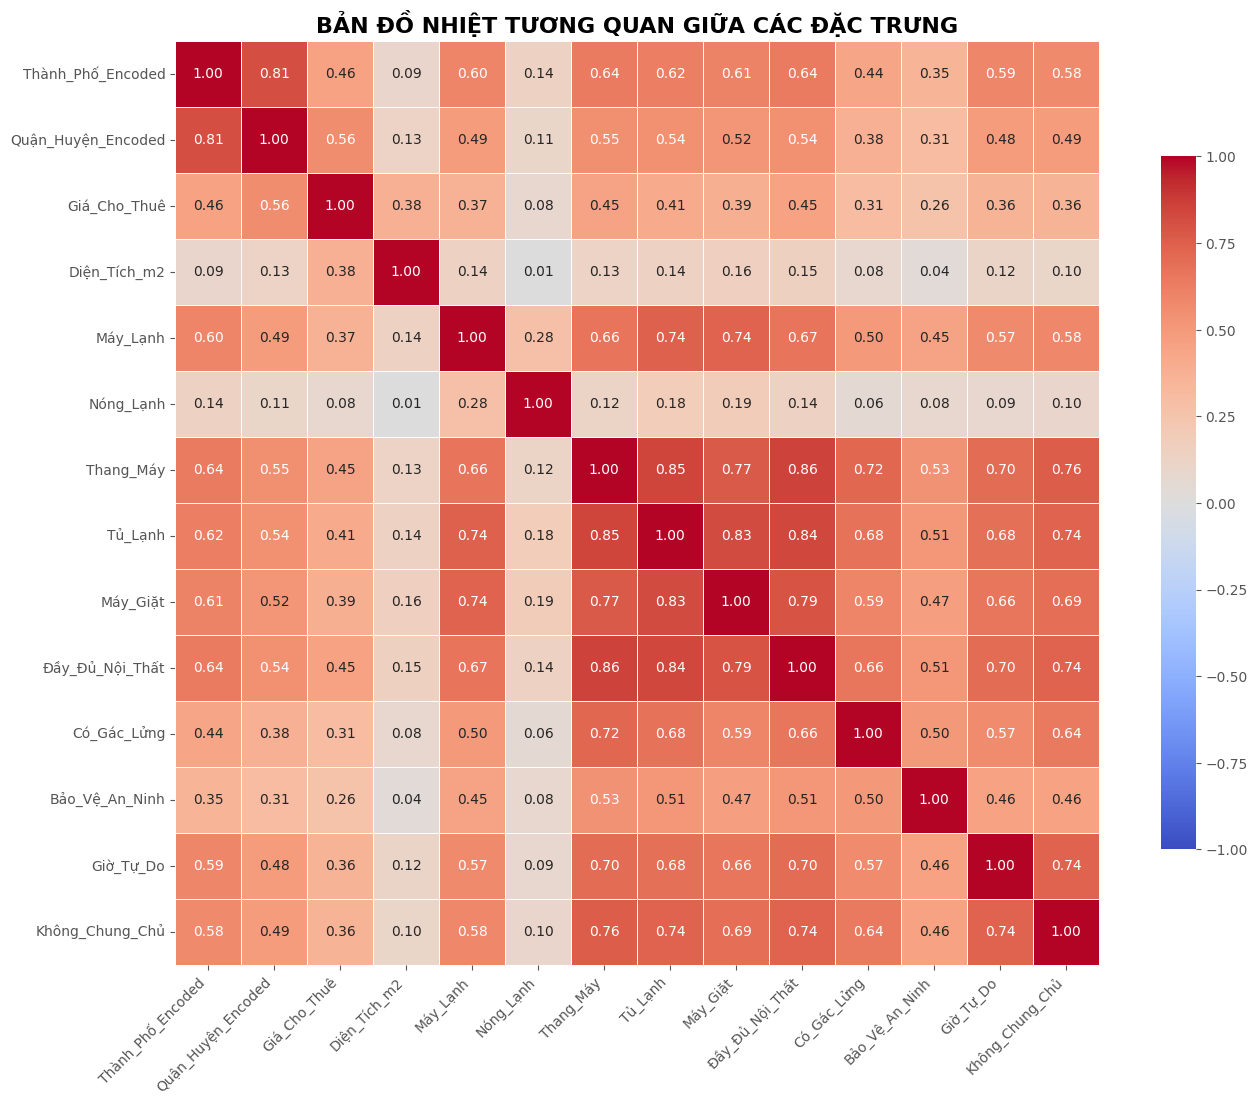

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cols_to_drop = ['Log_Giá', 'Log_Diện_Tích']
cols_to_drop = [c for c in cols_to_drop if c in df_clean.columns]

num_df = df_clean.select_dtypes(include=[np.number]).drop(columns=cols_to_drop)

# Tính ma trận tương quan Pearson
corr_matrix = num_df.corr()

# Lấy riêng cột Tương quan với Giá_Cho_Thuê và sắp xếp giảm dần
target_corr = corr_matrix['Giá_Cho_Thuê'].sort_values(ascending=False)
df_corr = pd.DataFrame({'Hệ số tương quan (với Giá)': target_corr})

print("\nBảng xếp hạng các yếu tố ảnh hưởng đến giá cho thuê phòng: ")
display(df_corr)

plt.figure(figsize=(16, 12))

# Vẽ heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .75})

plt.title('BẢN ĐỒ NHIỆT TƯƠNG QUAN GIỮA CÁC ĐẶC TRƯNG', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

### Nhận xét về đánh giá từ Hệ số tương quan
**1. Vị trí địa lý là yếu tố mang tính quyết định**
- `Quận_Huyện_Encoded` đạt hệ số tương quan cao nhất toàn bảng (**0.56**), ngay sau đó là `Thành_Phố_Encoded` (**0.45**). 
- **Giải thích:** Sinh viên luôn ưu tiên thuê phòng gần trường Đại học hoặc trung tâm thành phố. Giá phòng ở quận trung tâm luôn đắt hơn hẳn vùng ven.

**2. Nhóm tiện ích cao cấp làm thay đổi phân khúc giá**
- `Đầy_Đủ_Nội_Thất` (**0.45**) và `Thang_Máy` (**0.45**) có tác động làm tăng giá trị căn phòng lớn hơn cả độ rộng của Diện tích.
- Theo sau là các tiện nghi phần cứng như `Tủ_Lạnh` (0.41), `Máy_Giặt` (0.39), `Máy_Lạnh` (0.37). 
- **Giải thích:** Khách thuê phòng trọ ngày nay có xu hướng chuộng các dạng "Chung cư mini" hoặc "Căn hộ dịch vụ". Họ sẵn sàng trả giá rất cao cho một căn phòng xách vali vào là ở, thay vì phải mua sắm đồ đạc từ đầu.

**3. Diện tích lùi về thứ yếu so với Vị trí và Tiện nghi**
- `Diện_Tích_m2` có mức tương quan vừa phải (**0.37**) nhưng xếp hạng dưới các tiện ích nội thất. 
- **Giải thích:** Khách hàng chấp nhận ở một căn phòng nhỏ (15-20m2) nhưng đủ đồ và có thang máy ở trung tâm, thay vì thuê một căn phòng rất to (40m2) nhưng trống trơn ở ngoại thành.

**4. Sự riêng tư và các tiện ích cơ bản**
- Yếu tố `Giờ_Tự_Do` (0.36) và `Không_Chung_Chủ` (0.35) mang lại giá trị gia tăng tốt, vì giới trẻ cực kỳ quan tâm đến sự thoải mái, tự do.
- Trái lại, `Nóng_Lạnh` (0.08) có hệ số rất thấp, gần tiến về 0. Lý do có thể vì máy nước nóng đã trở thành một *tiêu chuẩn mặc định* tối thiểu ở đa số các phòng, nên nó không còn tạo ra sự đột biến về giá.

## 7. Trực quan hóa mối quan hệ giữa các biến

### 1. Biểu đồ tương quan đá bién (Diện tích - Giá - Thành phố)

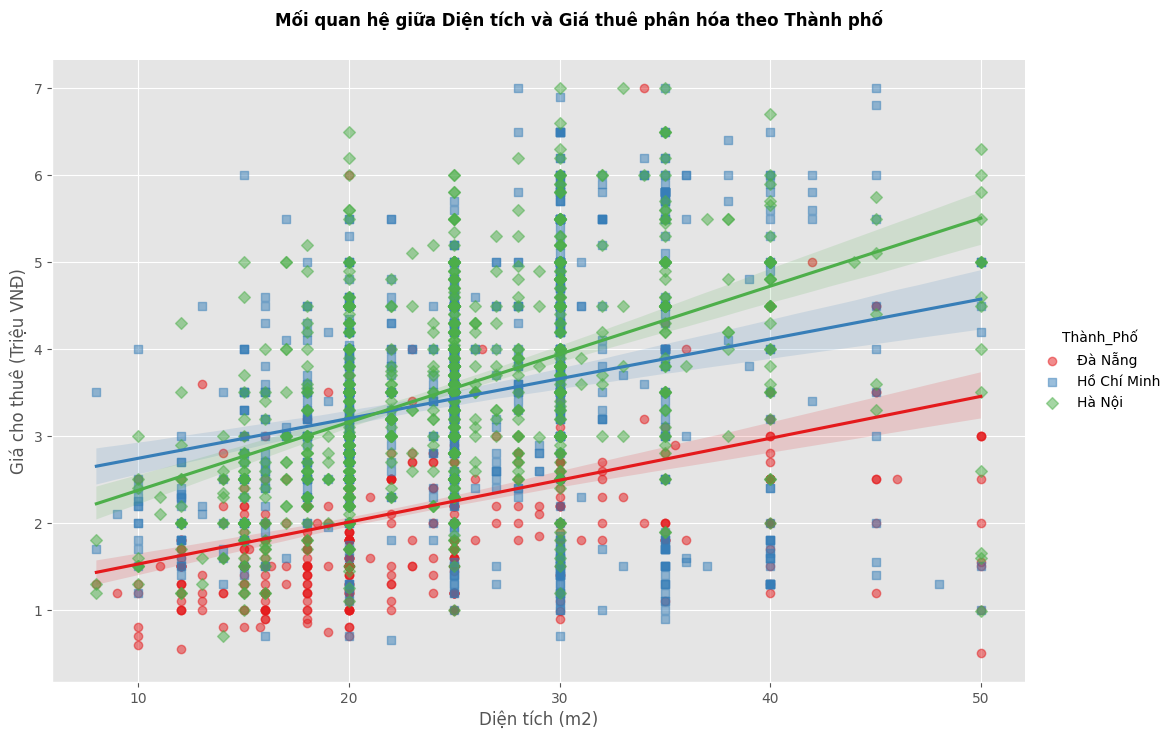

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lmplot
g = sns.lmplot(data=df_clean, x='Diện_Tích_m2',  y='Giá_Cho_Thuê', hue='Thành_Phố', height=7, aspect=1.5, markers=['o', 's', 'D'], palette='Set1', scatter_kws={'alpha':0.5})

g.fig.suptitle('Mối quan hệ giữa Diện tích và Giá thuê phân hóa theo Thành phố', fontweight='bold', y=1.05)
g.set_axis_labels('Diện tích (m2)', 'Giá cho thuê (Triệu VNĐ)')

plt.show()

### Nhận xét về mối quan hệ tuyến tính giữa Diện tích và Giá thuê
- Biểu đồ cho thấy sự phân hóa rõ nét về Độ dốc của đường hồi quy. Đường xu hướng của Hà Nội và TP.HCM có độ dốc cao hơn hẳn so với Đà Nẵng.
- Cùng một mức tăng về diện tích, giá phòng ở khu vực thủ đô Hà Nội và TP.HCM sẽ tăng vọt mạnh mẽ hơn rất nhiều. Trong khi đó ở Đà Nẵng, giá phòng tăng khá bình ổn, và chậm rãi theo diện tích.

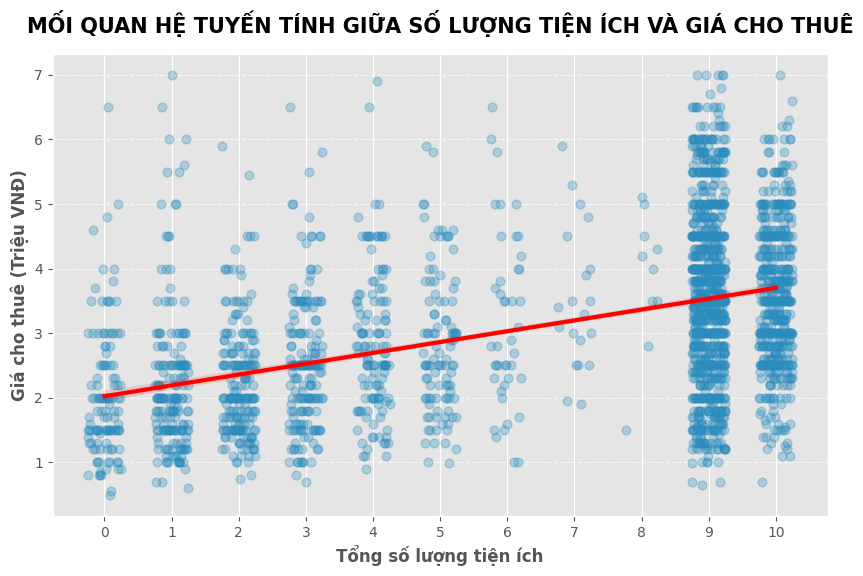

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Danh sách 10 cột tiện ích đã trích xuất
utility_cols = ['Máy_Lạnh', 'Nóng_Lạnh', 'Thang_Máy', 'Tủ_Lạnh', 'Máy_Giặt', 
                'Đầy_Đủ_Nội_Thất', 'Có_Gác_Lửng', 'Bảo_Vệ_An_Ninh', 'Giờ_Tự_Do', 'Không_Chung_Chủ']

if 'Tổng_Tiện_Ích' not in df_clean.columns:
    df_clean['Tổng_Tiện_Ích'] = df_clean[utility_cols].sum(axis=1)

# Vẽ biểu đồ quan hệ tuyến tính
plt.figure(figsize=(10, 6))

sns.regplot(data=df_clean, x='Tổng_Tiện_Ích', y='Giá_Cho_Thuê', 
            scatter_kws={'alpha': 0.3, 'color': '#2b8cbe', 's': 40}, 
            line_kws={'color': 'red', 'linewidth': 3},                
            x_jitter=0.25)

# nhãn và tiêu đề
plt.title('MỐI QUAN HỆ TUYẾN TÍNH GIỮA SỐ LƯỢNG TIỆN ÍCH VÀ GIÁ CHO THUÊ', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Tổng số lượng tiện ích', fontsize=12, fontweight='bold')
plt.ylabel('Giá cho thuê (Triệu VNĐ)', fontsize=12, fontweight='bold')

plt.xticks(np.arange(0, 11, 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Nhận xét về mối quan hệ tuyến tính giữa Tổng lượng tiện ích và Giá phòng:

**1. Tương quan thuận (Đồng biến) rõ rệt:**
- Đường xu hướng hồi quy (màu đỏ) có độ dốc hướng lên cực kỳ ổn định. Điều này khẳng định quy luật: **Số lượng tiện ích tỷ lệ thuận với Giá thuê**. Mỗi khi căn phòng được trang bị thêm tiện ích mới, mặt bằng giá chung sẽ được đẩy lên một nấc.

**2. Hiện tượng phân tán mạnh tại nhóm 9-10 tiện ích (Phân khúc "Full nội thất"):**
- Điểm đáng chú ý nhất là tại mốc 9 và 10 tiện ích, các điểm dữ liệu tụ lại cực kỳ dày đặc và kéo dài biên độ giá rất rộng (trải dài từ mức giá siêu rẻ 1.5 triệu đến mức rất đắt 7-8 triệu).
- **Giải thích:** Ở phân khúc phòng trọ cao cấp (đầy đủ 10 tiện ích), **Vị trí và Diện tích** sẽ đóng vai trò quyết định mức giá cuối cùng. Một căn phòng "full đồ" nhưng chật hẹp ở ngoại thành sẽ nằm ở đáy biểu đồ, trong khi căn hộ studio rộng rãi ở lõi trung tâm sẽ vút lên đỉnh biểu đồ.

**3. Đặc thù nguồn cung của thị trường:**
- Dữ liệu thưa thớt ở mốc 6-8 tiện ích nhưng lại dày kịt ở mốc 9-10 tiện ích cho thấy sự phân cực của thị trường cho thuê hiện nay: Các chủ nhà thường có xu hướng đầu tư theo dạng Xách vali vào ở (trang bị đầy đủ toàn bộ từ máy lạnh, tủ lạnh, thang máy...) để tối ưu hóa lợi nhuận, thay vì làm các căn phòng tiện ích lỡ cỡ.

### Biểu đồ so sánh giá trung bình theo thành phố

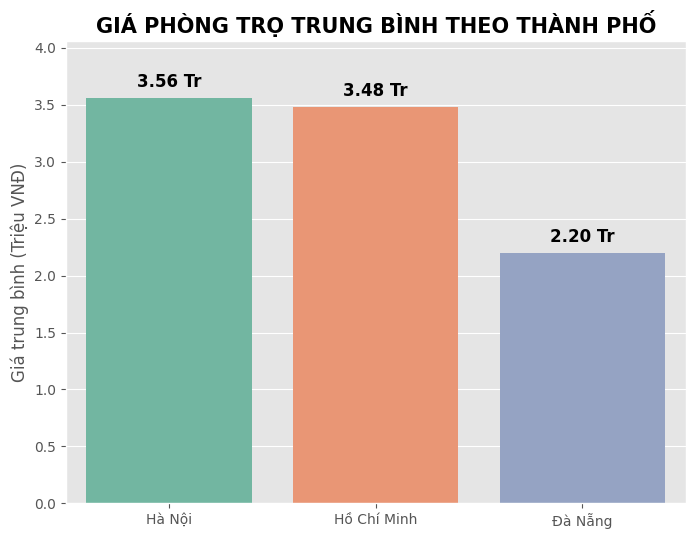

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tính giá trung bình
city_avg = df_clean.groupby('Thành_Phố')['Giá_Cho_Thuê'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8, 6))
ax = sns.barplot(data=city_avg, x='Thành_Phố', y='Giá_Cho_Thuê', palette='Set2')

plt.title('GIÁ PHÒNG TRỌ TRUNG BÌNH THEO THÀNH PHỐ', fontsize=15, fontweight='bold')
plt.ylabel('Giá trung bình (Triệu VNĐ)', fontsize=12)
plt.xlabel('')

# Ghi số liệu lên đỉnh từng cột
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f} Tr", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')

plt.ylim(0, city_avg['Giá_Cho_Thuê'].max() + 0.5)
plt.show()

### Biểu đồ so sánh giá trung bình ở các quận, huyện trên 3 thành phố

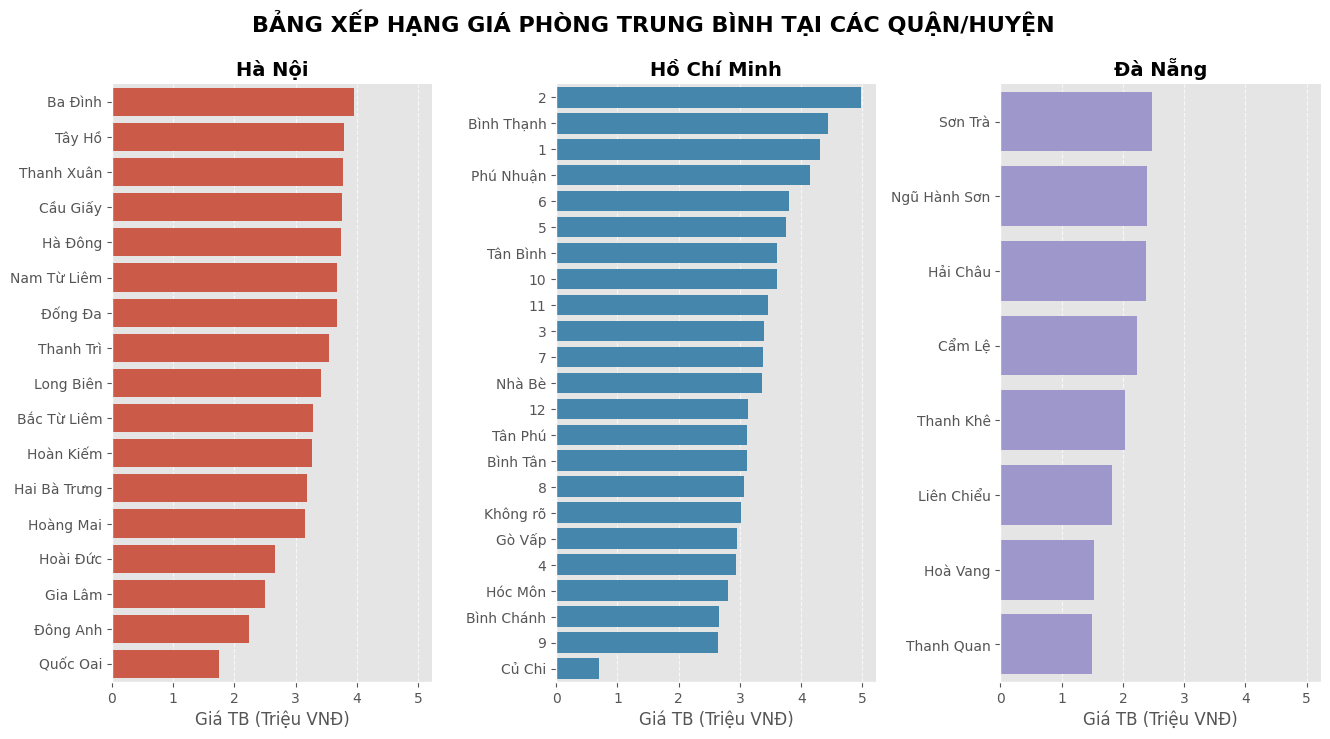

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tính giá trung bình của từng quận huyện
district_avg = df_clean.groupby(['Thành_Phố', 'Quận_Huyện'])['Giá_Cho_Thuê'].mean().reset_index()

# Sắp xếp giá giảm dần 
district_avg = district_avg.sort_values(['Thành_Phố', 'Giá_Cho_Thuê'], ascending=[True, False])

# Vẽ biểu đồ Catplot chia thành 3 cột (FacetGrid)
g = sns.catplot(
    data=district_avg, 
    x='Giá_Cho_Thuê', 
    y='Quận_Huyện', 
    col='Thành_Phố', 
    kind='bar',
    height=7, 
    aspect=0.65,     
    sharey=False,    
    hue='Thành_Phố',  
    dodge=False,
    legend=False
)

# Tùy chỉnh tiêu đề và nhãn
g.fig.suptitle('BẢNG XẾP HẠNG GIÁ PHÒNG TRUNG BÌNH TẠI CÁC QUẬN/HUYỆN', fontsize=16, fontweight='bold', y=1.05)
g.set_axis_labels('Giá TB (Triệu VNĐ)', '')
g.set_titles("{col_name}", size=14, fontweight='bold')

for ax in g.axes.flat:
    ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

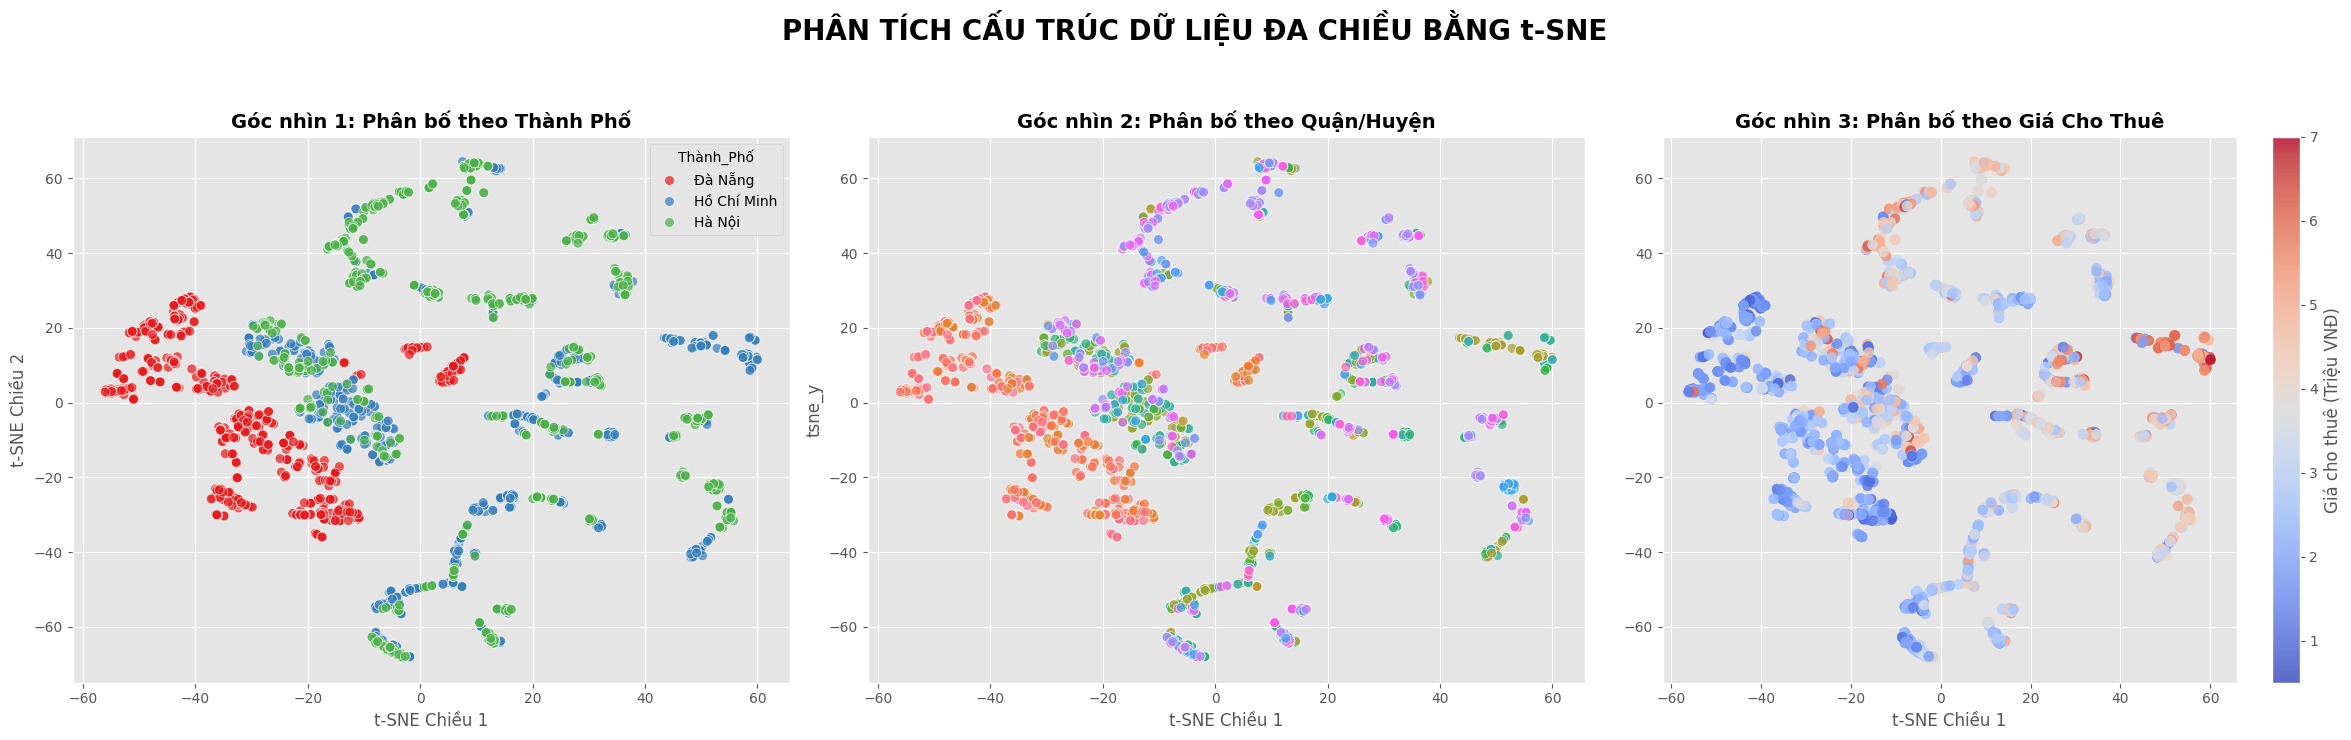

In [38]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Lựa chọn các biến đặc trưng đưa vào máy học
features_for_tsne = df_clean.drop(columns=['Thành_Phố', 'Quận_Huyện', 'Giá_Cho_Thuê', 'Log_Giá', 'Log_Diện_Tích'])

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_for_tsne)

# Chạy t-SNE (CHỈ CHẠY 1 LẦN DUY NHẤT)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
tsne_result = tsne.fit_transform(X_scaled)

# Lưu tọa độ vào df_clean tạm thời để vẽ
df_clean['tsne_x'] = tsne_result[:,0]
df_clean['tsne_y'] = tsne_result[:,1]

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle('PHÂN TÍCH CẤU TRÚC DỮ LIỆU ĐA CHIỀU BẰNG t-SNE', fontsize=20, fontweight='bold', y=1.05)

# Biểu đồ 1: Phân cụm theo thành phố
sns.scatterplot(ax=axes[0], x="tsne_x", y="tsne_y", hue="Thành_Phố", 
                palette="Set1", data=df_clean, alpha=0.7, s=50)
axes[0].set_title('Góc nhìn 1: Phân bố theo Thành Phố', fontsize=14, fontweight='bold')
axes[0].set_xlabel('t-SNE Chiều 1')
axes[0].set_ylabel('t-SNE Chiều 2')

# Biểu đồ 2: Phân cụm theo Quận / Huyện
sns.scatterplot(ax=axes[1], x="tsne_x", y="tsne_y", hue="Quận_Huyện", 
                palette="husl", data=df_clean, legend=False, alpha=0.7, s=50)
axes[1].set_title('Góc nhìn 2: Phân bố theo Quận/Huyện', fontsize=14, fontweight='bold')
axes[1].set_xlabel('t-SNE Chiều 1')

# Biểu đồ 3: Phân bố theo giá cho thuê
scatter = axes[2].scatter(df_clean['tsne_x'], df_clean['tsne_y'], 
                          c=df_clean['Giá_Cho_Thuê'], cmap='coolwarm', alpha=0.8, s=50)
axes[2].set_title('Góc nhìn 3: Phân bố theo Giá Cho Thuê', fontsize=14, fontweight='bold')
axes[2].set_xlabel('t-SNE Chiều 1')

cbar = plt.colorbar(scatter, ax=axes[2])
cbar.set_label('Giá cho thuê (Triệu VNĐ)')

plt.tight_layout()
plt.show()

df_clean = df_clean.drop(columns=['tsne_x', 'tsne_y'])

## Nhận xét về cấu trúc phân cụm tiềm ẩn từ t-SNE:

**1. Góc nhìn 1: Phân bố theo Thành Phố**
- Các điểm dữ liệu của **Đà Nẵng** tụ lại thành một mảng phân bổ hoàn toàn độc lập và tách biệt. Điều này chứng tỏ đặc thù về diện tích và tiện ích phòng trọ ở Đà Nẵng có sự khác biệt rất lớn so với 2 miền còn lại.
- Trái lại, **Hà Nội** và **TP.HCM** lại có sự giao thoa và chồng lấn lên nhau ở vùng trung tâm. Điều này phản ánh thực tế: Cơ sở hạ tầng, xu hướng xây dựng (chung cư mini) và lối sống của sinh viên ở 2 siêu đô thị lớn nhất nước ta có cấu trúc cực kỳ tương đồng.

**2. Góc nhìn 2: Phân bố theo Quận / Huyện**
- Các chấm màu biểu diễn cho các Quận/Huyện không bị phân tán ngẫu nhiên mà có xu hướng tụ lại thành từng mảng màu cục bộ. 
- **Ý nghĩa:** Những căn phòng trọ nằm trong cùng một Quận (cùng một khu vực địa lý) thường có sự tương đồng rất cao về diện tích, mức độ đầu tư tiện ích nội thất và đối tượng khách thuê.

**3. Góc nhìn 3: Phân bố theo Giá Cho Thuê (Điểm nhấn quan trọng nhất)**
- Thuật toán t-SNE *hoàn toàn không được cung cấp thông tin về giá tiền*, nhưng khi dải màu Gradient (từ xanh đến đỏ) được áp lên: Các chấm màu Đỏ đậm (Giá cực cao) tự động gom tụ về một phía, trong khi các chấm màu Xanh (Giá rẻ) nằm tách biệt sang phía đối diện. Có một sự chuyển tiếp màu sắc rất mượt mà dọc theo trục tọa độ.
- **Ý nghĩa:** Chỉ cần dựa vào Tiện ích và Diện tích, máy tính đã tự động nhóm được phòng giá rẻ và phòng cao cấp ra riêng rẽ.

### Biểu đồ mật độ phân bố giá theo thành phố

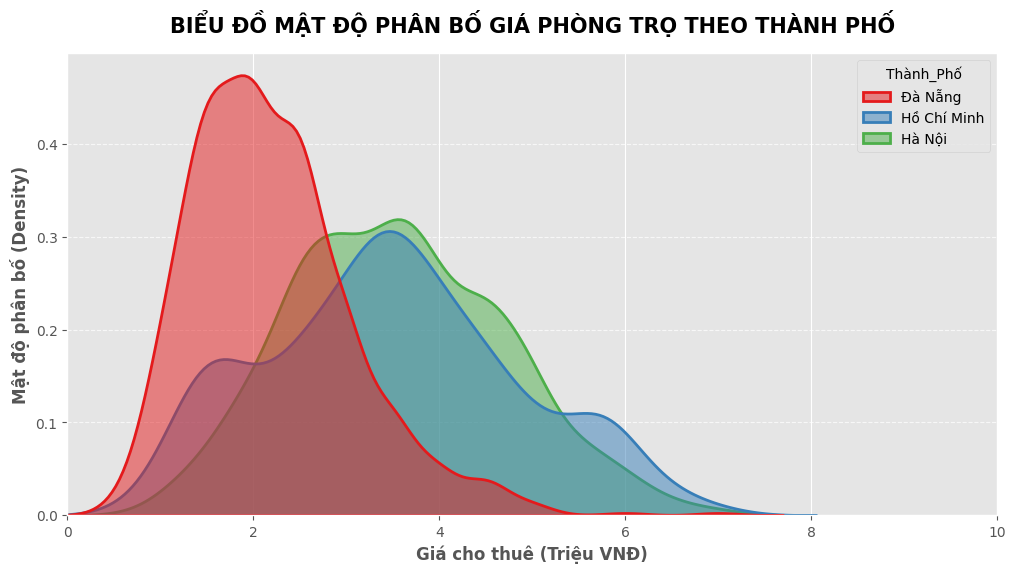

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.kdeplot(data=df_clean, x='Giá_Cho_Thuê', hue='Thành_Phố', 
            fill=True, common_norm=False, palette='Set1', alpha=0.5, linewidth=2)

# tiêu đề và nhãn
plt.title('BIỂU ĐỒ MẬT ĐỘ PHÂN BỐ GIÁ PHÒNG TRỌ THEO THÀNH PHỐ', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Giá cho thuê (Triệu VNĐ)', fontsize=12, fontweight='bold')
plt.ylabel('Mật độ phân bố (Density)', fontsize=12, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.xlim(0, 10) 

plt.show()

### Nhận xét từ Biểu đồ mật độ phân bố giá (Density Plot):

**1. Đỉnh phân bố (Mức giá phổ biến nhất):**
- **Đà Nẵng:** Đỉnh cao nhất và lệch hẳn về phía bên trái (khoảng 1.5 - 2 triệu VNĐ). Điều này cho thấy nguồn cung phòng trọ ở Đà Nẵng tập trung tuyệt đối vào phân khúc giá rẻ. Đường cong hẹp cũng chứng tỏ mức giá ở đây ít có sự chênh lệch hay biến động lớn.
- **Hà Nội và TP.HCM:** Đỉnh của đường cong thấp hơn và nằm dịch sang bên phải (quanh mức 2.5 - 3.5 triệu VNĐ). Đây là mức giá phổ biến mà sinh viên/người đi làm phải trả khi sống tại hai đô thị này.

**2. Độ trải rộng của dữ liệu:**
- Đường cong của Đà Nẵng tụt dốc rất nhanh và gần như chạm đáy ở mức 4-5 triệu.
- Trái lại, phần đuôi (nhánh bên phải) của Hà Nội và TP.HCM kéo dài và lài ra rất xa (kéo dài đến tận mức 6-8 triệu). 
- **Giải thích:** Hiện tượng này minh chứng cho sự tồn tại của phân khúc ngách.Ở hai siêu đô thị này, khoảng cách giàu nghèo và nhu cầu sống tiện nghi rất đa dạng, nên mức giá cũng phân hóa cực kỳ rộng.


### Biểu đồ phân bố giá theo thành phố

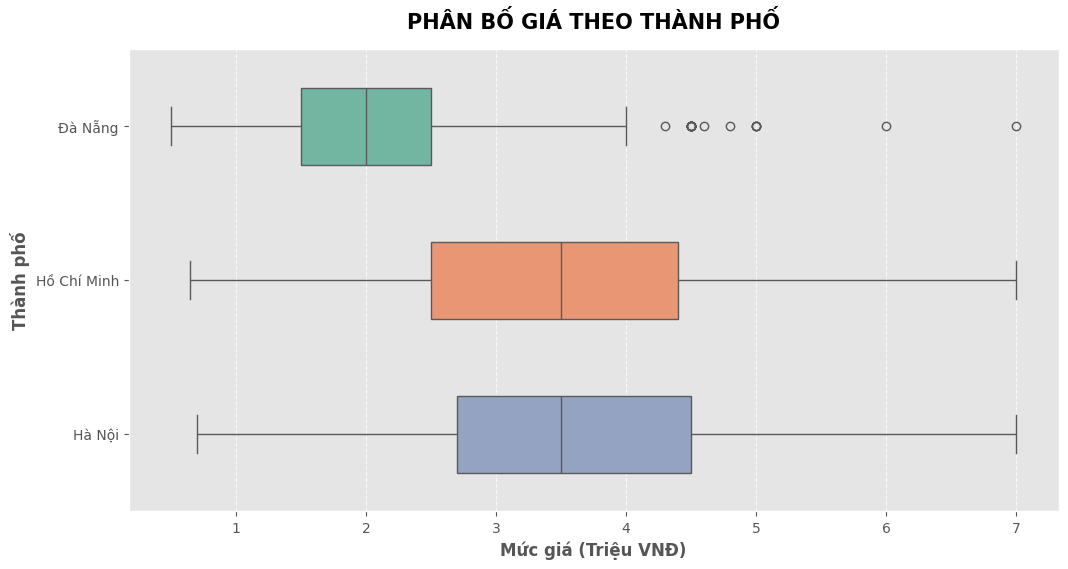

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Vẽ biểu đồ Boxplot
sns.boxplot(data=df_clean, x='Giá_Cho_Thuê', y='Thành_Phố', palette='Set2', width=0.5)

# tiêu đề và nhãn
plt.title('PHÂN BỐ GIÁ THEO THÀNH PHỐ', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Mức giá (Triệu VNĐ)', fontsize=12, fontweight='bold')
plt.ylabel('Thành phố', fontsize=12, fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

### Nhận xét từ Biểu đồ Boxplot (Phân bố giá theo Thành phố):

**1. Về mức giá trung tâm (Đường trung vị nằm giữa hộp):**
- **Hà Nội** là thành phố có mức giá trung vị cao nhất, theo sát ngay sau là **TP.HCM**. 
- **Đà Nẵng** có mức giá thấp nhất và cách biệt hoàn toàn.

**2. Về độ phân tán dữ liệu (Chiều cao của hộp):**
- Hộp của **Đà Nẵng** rất hẹp, chứng tỏ giá phòng ở đây cực kỳ đồng đều, ít có sự chênh lệch lớn và chủ yếu tập trung ở phân khúc giá rẻ.
- Hộp của **Hà Nội** và **TP.HCM** trải dài hơn rất nhiều, cho thấy thị trường ở đây cực kỳ đa dạng phân khúc, từ phòng trọ sinh viên giá rẻ đến các căn phòng đắt tiền.

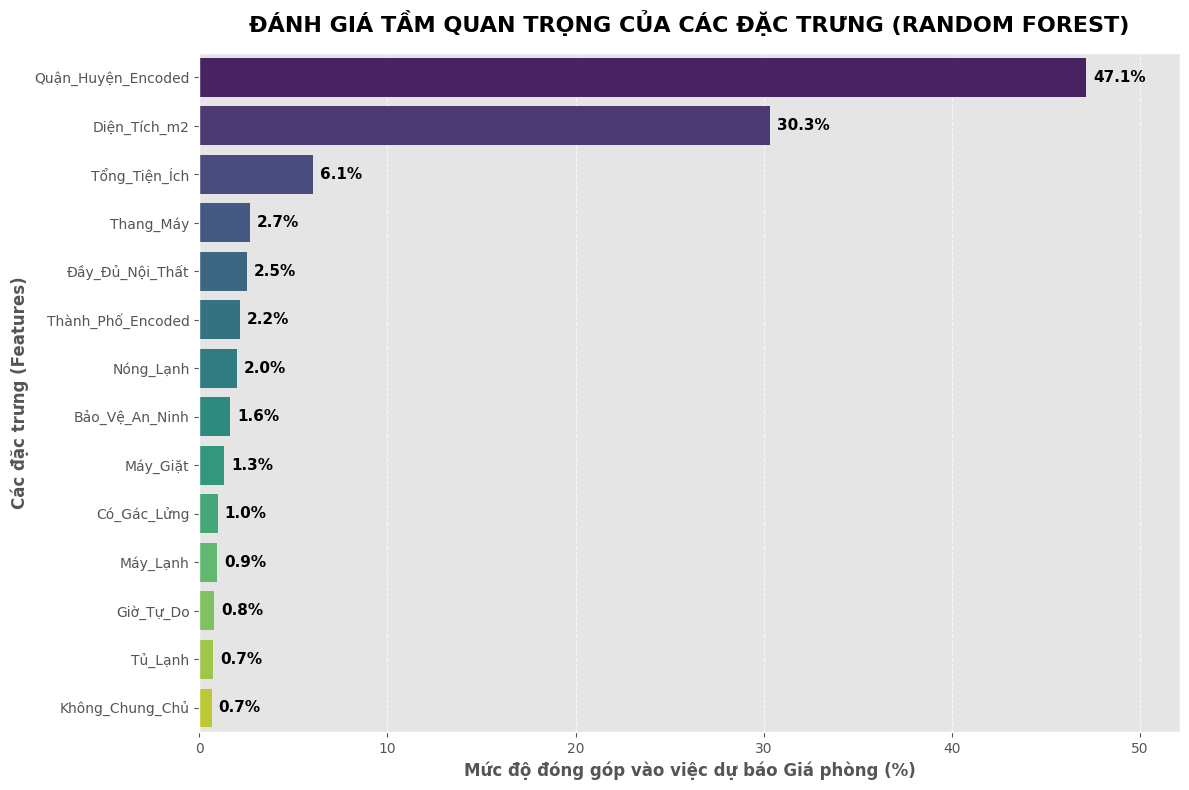

In [57]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

features_to_drop = ['Thành_Phố', 'Quận_Huyện', 'Giá_Cho_Thuê', 'Log_Giá', 'Log_Diện_Tích']
X = df_clean.drop(columns=features_to_drop)
y = df_clean['Giá_Cho_Thuê']

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)

feature_importances = pd.Series(rf_model.feature_importances_ * 100, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(12, 8))
ax = sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')

# Tùy chỉnh biểu đồ
plt.title('ĐÁNH GIÁ TẦM QUAN TRỌNG CỦA CÁC ĐẶC TRƯNG (RANDOM FOREST)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Mức độ đóng góp vào việc dự báo Giá phòng (%)', fontsize=12, fontweight='bold')
plt.ylabel('Các đặc trưng (Features)', fontsize=12, fontweight='bold')

for p in ax.patches:
    ax.annotate(f"{p.get_width():.1f}%", 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', fontsize=11, fontweight='bold', color='black', xytext=(5, 0), textcoords='offset points')

plt.xlim(0, feature_importances.max() + 5)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Nhận xét từ Mô hình Random Forest:

Khác với Hệ số tương quan (chỉ xét từng cặp biến độc lập), Random Forest đánh giá sự phối hợp tổng thể của toàn bộ dữ liệu. Kết quả cho thấy 3 nhóm động lực chính quyết định Giá phòng:

**1. Vị trí cấp cơ sở là nhất (Trọng số ~47%):**
- `Quận_Huyện_Encoded` chiếm tới gần một nửa quyết định giá phòng. 
- **Giải thích:** Máy tính nhận ra rằng việc biết phòng nằm ở Đà Nẵng hay Hà Nội không quan trọng bằng việc biết nó nằm ở Quận Cầu Giấy (lõi trung tâm) hay Huyện Bình Chánh (ngoại thành). 

**2. Độ rộng của căn phòng (Trọng số ~30%):**
- Sau khi đã cố định được Vị trí (Quận), thì diện tích to hay nhỏ là yếu tố vật lý cốt lõi nhất để chủ nhà tính tiền thuê.

**3. Khối Tiện ích (Trọng số ~20% tổng cộng):**
- Thay vì xét lẻ tẻ, máy tính đánh giá rất cao biến `Tổng_Tiện_Ích` (~6%) cùng các tiện ích như `Thang_Máy` và `Đầy_Đủ_Nội_Thất`. Điều này cho thấy việc có nhiều tiện ích đi kèm sẽ tạo ra một hiệu ứng cộng hưởng, đẩy giá phòng lên cao hơn rất nhiều so với chỉ có một vài tiện ích đơn lẻ.

## 8. Kết luận
Dựa trên quá trình Khám phá và Phân tích dữ liệu, có thể khẳng định bài toán dự đoán giá phòng trọ là **hoàn toàn khả thi về mặt dữ liệu**. Biến mục tiêu (Giá cho thuê) không biến động ngẫu nhiên mà có sự phụ thuộc rất chặt chẽ và có quy luật vào các đặc trưng đã được trích xuất. 

Thông qua các phương pháp trực quan hóa không gian đa chiều và thuật toán đánh giá trọng số, những đặc trưng mang tính quyết định, có thể sử dụng trực tiếp để xây dựng mô hình dự đoán bao gồm:
* **Vị trí địa lý (Quận/Huyện, Thành phố):** Đóng vai trò nền tảng, định hình toàn bộ mặt bằng và phân khúc giá.
* **Diện tích (m2):** Yếu tố cốt lõi, có tương quan thuận trực tiếp và mạnh mẽ với mức giá thuê.
* **Hệ sinh thái tiện ích (Tổng số tiện ích, Thang máy, Nội thất...):** Yếu tố tạo ra sự đột biến về giá, giúp phân tách rõ rệt giữa phòng trọ sinh viên truyền thống và cao cấp.

## 9. Tài liệu tham khảo
* https://phamdinhkhanh.github.io/2019/01/07/Ky_thuat_feature_engineering.html
* https://www.datacamp.com/tutorial/introduction-t-sne
* https://www.datacamp.com/tutorial/random-forests-classifier-python?utm_aid=157156376311&utm_loc=9047170-&utm_mtd=-c&utm_kw=&gad_campaignid=19589720824